# Resultados del proyecto — Lab 02 · Equipo 3

Todos los resultados del proyecto en un solo lugar. El notebook **solo carga** `results/` y las
figuras de `docs/figuras/` que genera `python main.py`; no recalcula ni reoptimiza nada
(CLAUDE.md, secciones 9 y 10).

Orden: corrida → datos → régimen (P3) → portafolio (P4) → corrida base (P1) → diagnóstico y
robustez (P2) → walk-forward → desempeño por régimen → backtests finales → impacto de mercado y
auditoría de sesgos.

In [1]:
import os
import pickle
from pathlib import Path

# Los pickles guardan objetos de src/ (por ejemplo, BacktestResult): se trabaja desde la raíz.
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import pandas as pd
from IPython.display import Image, Markdown, display

RESULTS = Path("results")
FIGURES = Path("docs") / "figuras"
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.4f}".format)

r = {path.stem: pickle.load(open(path, "rb")) for path in sorted(RESULTS.glob("*.pkl"))}
sorted(r)

['corrida',
 'corrida_base',
 'datos_regimen',
 'diagnostico',
 'final_backtests',
 'impacto_mercado',
 'portafolio',
 'regimen',
 'regimen_desempeno',
 'robustez',
 'walk_forward']

## Corrida

In [2]:
corrida = r["corrida"]
display(pd.Series(corrida))
if not corrida["final_run"]:
    display(Markdown("**Corrida previa: los datos terminan en validation y test no se tocó.**"))

commit                 ee16b91888d559d976b9ae96e544ec46c7516b17
uncommitted_changes                                        True
final_run                                                 False
elapsed_seconds                                      1,590.9214
finished                                    2026-10-06 17:16:17
dtype: object

**Corrida previa: los datos terminan en validation y test no se tocó.**

## Datos y auditoría (P1)

In [3]:
display(r["datos_regimen"]["audit"])

,n_obs,start,end,nan,non_positive,high_lt_low,open_outside,close_outside,zero_volume,dropped_dates
AAPL,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
MSFT,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
META,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
AMD,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
XOM,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
SMH,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
GLD,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
COPX,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0


## Régimen de mercado (P3)

### Comparación de métodos (ajuste en train, validation con el modelo congelado)

In [4]:
display(r["regimen"]["comparison"])

silhouette  duracion_media  transiciones_por_mes  pct_tendencia  pct_reversion  pct_crisis
metodo bloque                                                                                                
rules  train           0.2347         11.2000                1.8542        41.6667        38.2937     20.0397
       validation      0.3378         25.0500                0.7917        27.7445        20.3593     51.8962
kmeans train           0.3845         17.0847                1.2083        31.5476        61.9048      6.5476
       validation      0.3003         16.1613                1.2500        19.3613        80.6387      0.0000
hmm    train           0.2039         67.2000                0.2917        61.1111        26.3889     12.5000
       validation      0.1987        167.0000                0.0833        27.9441        72.0559      0.0000

### Etiqueta operable: validación por bloque y % de tiempo en cada régimen

In [5]:
display(r["regimen"]["validation_by_block"])
display(r["regimen"]["validation"]["pct_tiempo"].round(1))
display(r["regimen"]["validation"]["duracion_por_regimen"].rename("duración media (días)"))

,silhouette,duracion_media,transiciones_por_mes
train,0.1317,12.4444,1.6667
validation,0.3432,19.2692,1.0417


regime,tendencia,reversion,crisis
train,40.0000,27.6000,32.4000
validation,30.3000,18.6000,51.1000


first
crisis      64.7778
reversion    7.5714
tendencia   11.5625
Name: duración media (días), dtype: float64

### Etiqueta filtrada contra Viterbi

Coincidencia HMM filtrada vs Viterbi: 98.8%


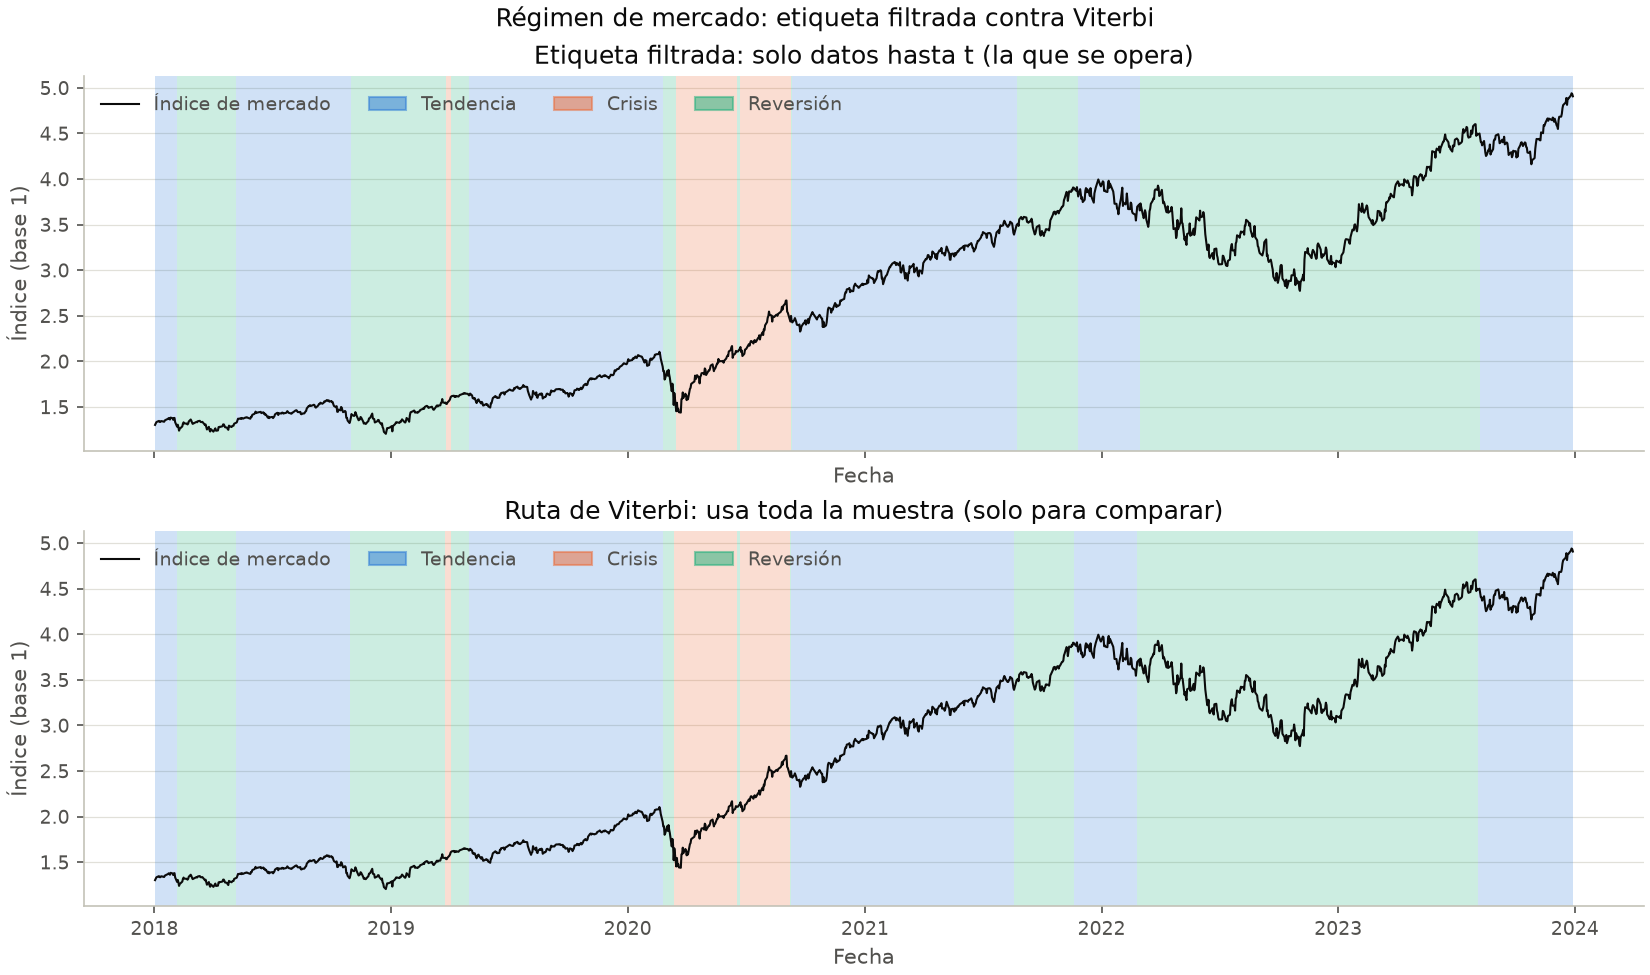

In [6]:
print(f"Coincidencia HMM filtrada vs Viterbi: {r['regimen']['hmm_agreement']:.1%}")
display(Image(filename=FIGURES / "regimen_filtrada_vs_viterbi.png"))

### Variables y correlación por régimen (train)

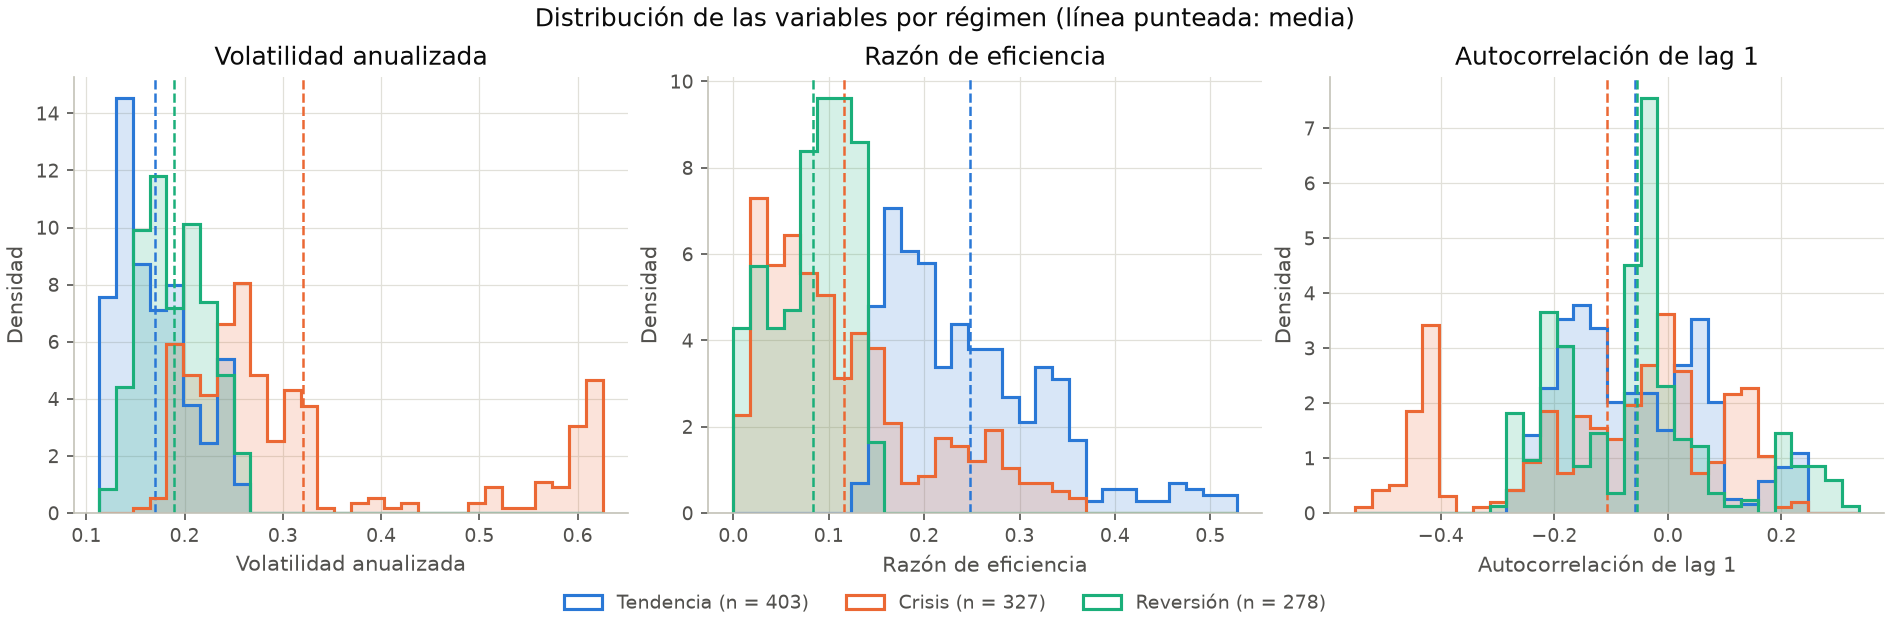

In [7]:
display(Image(filename=FIGURES / "regimen_variables_train.png"))

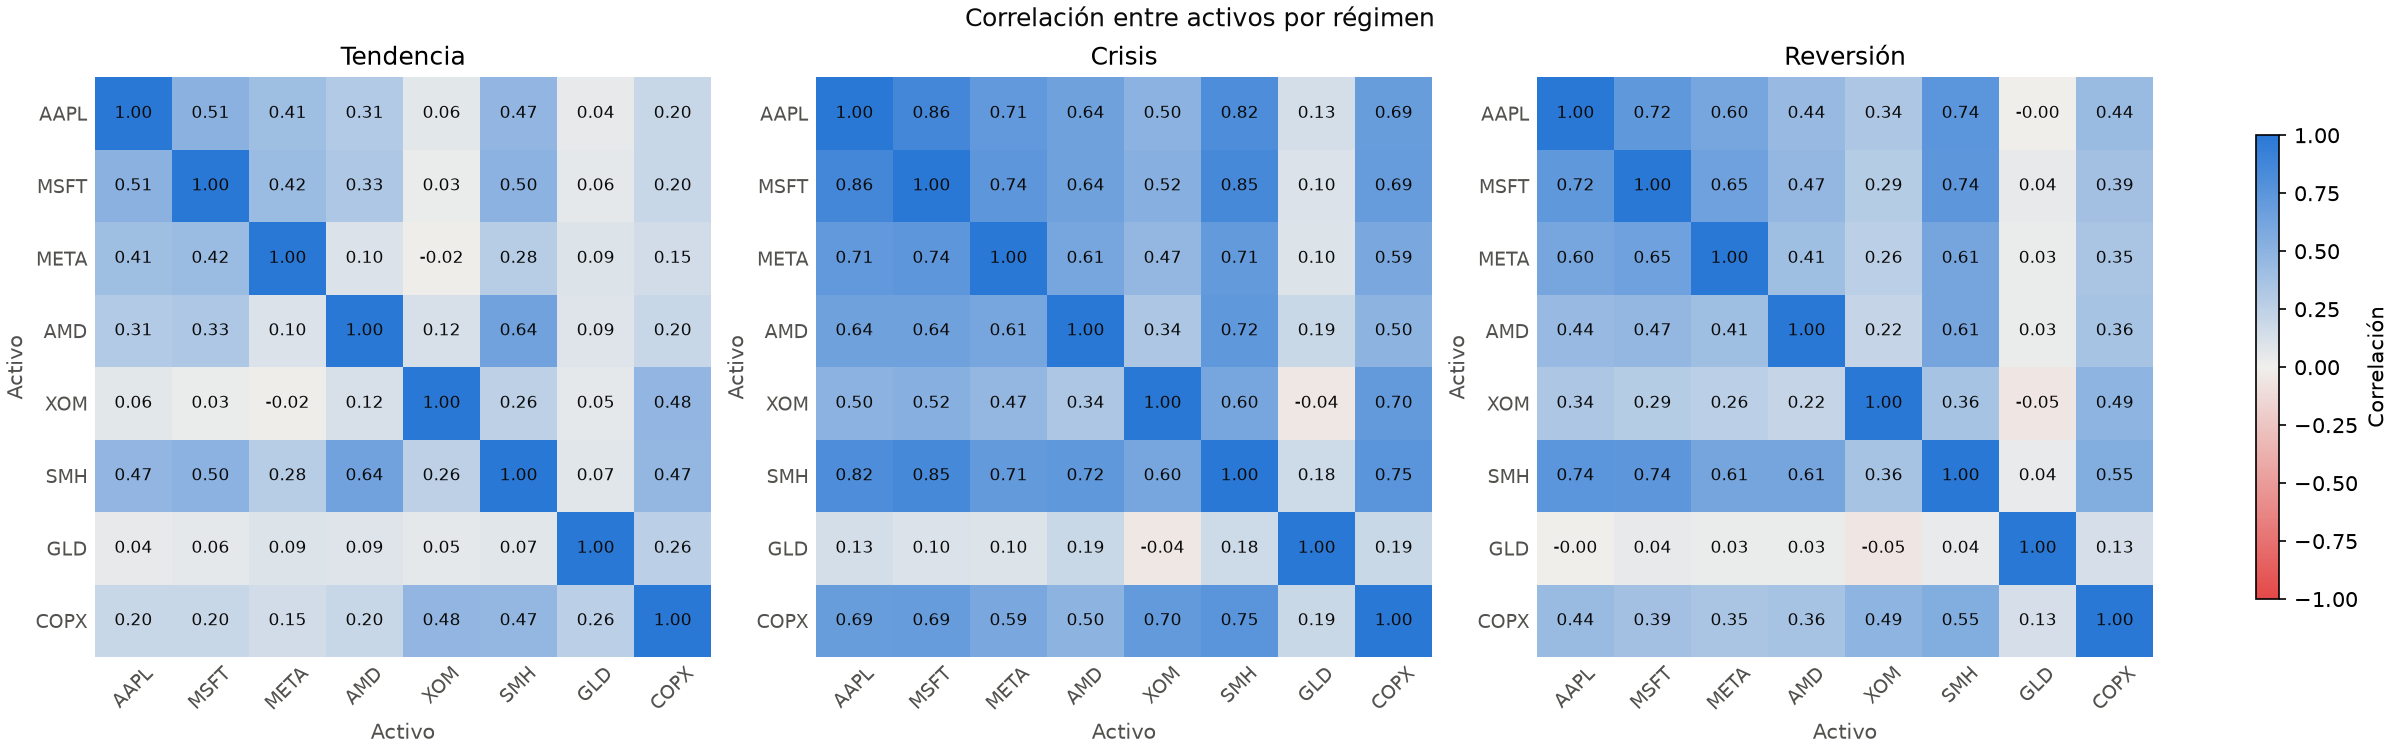

In [8]:
display(Image(filename=FIGURES / "regimen_correlacion_train.png"))

## Portafolio con θ base, train (P4)

### Estabilidad de los pesos por estimador

In [9]:
display(r["portafolio"]["weight_stability"])

,AAPL,MSFT,META,AMD,XOM,SMH,GLD,COPX,mean_std,n_reviews
sample,0.0192,0.0223,0.0151,0.0172,0.0297,0.0123,0.0908,0.0131,0.0275,48
ewma,0.0204,0.0225,0.0154,0.0176,0.0277,0.0125,0.0905,0.0125,0.0274,48
ledoit_wolf,0.0178,0.0191,0.0113,0.0163,0.0266,0.0111,0.0706,0.0114,0.0230,48


### Contribuciones al riesgo: Risk Parity contra pesos iguales

,AAPL,MSFT,META,AMD,XOM,SMH,GLD,COPX,spread,ann_vol
risk_parity,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.0000,0.1659
equal,0.1303,0.1170,0.1336,0.2365,0.0871,0.1483,0.0162,0.1309,0.2206,0.2218


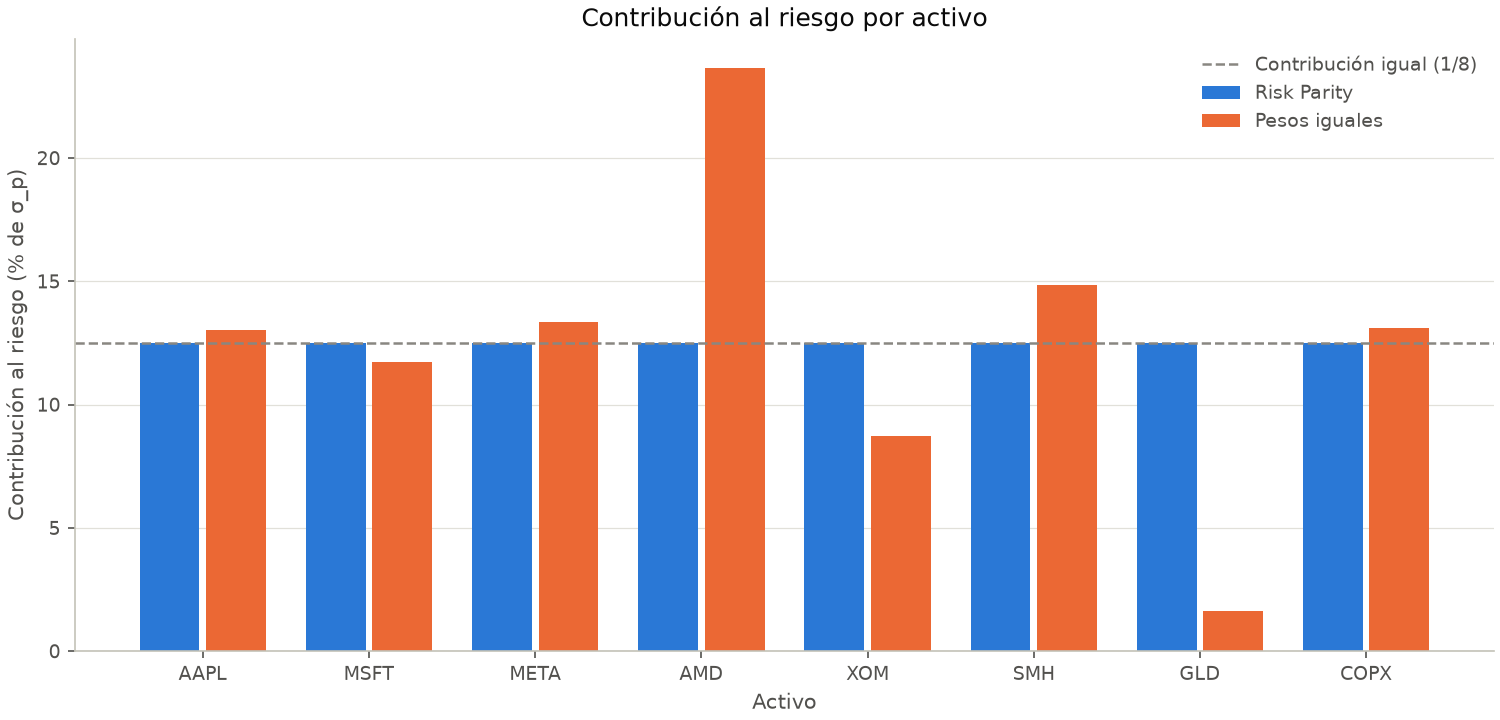

In [10]:
display(r["portafolio"]["risk_contributions"])
display(Image(filename=FIGURES / "portafolio_contribuciones_riesgo.png"))

### Risk Parity, pesos iguales y activos individuales

In [11]:
columnas = ["ann_return", "ann_vol", "sharpe", "calmar", "max_drawdown", "n_trades", "win_rate"]
display(r["portafolio"]["performance"]["train"][columnas])

,ann_return,ann_vol,sharpe,calmar,max_drawdown,n_trades,win_rate
risk_parity,0.0005,0.0134,-0.7615,0.0208,-0.0252,375,0.4427
equal,0.0031,0.0132,-0.5799,0.1556,-0.0197,375,0.4427
AAPL,0.0492,0.0446,0.8570,0.7742,-0.0636,45,0.5778
MSFT,-0.0008,0.0440,-0.2426,-0.0091,-0.0917,47,0.3830
META,-0.0087,0.0525,-0.3457,-0.1159,-0.0750,47,0.4255
AMD,0.0262,0.0470,0.3434,0.2963,-0.0884,56,0.4286
XOM,0.0080,0.0441,-0.0425,0.0565,-0.1417,45,0.4222
SMH,-0.0134,0.0449,-0.5183,-0.1753,-0.0762,43,0.4186
GLD,-0.0185,0.0439,-0.6506,-0.1824,-0.1014,48,0.3958
COPX,0.0324,0.0464,0.4776,0.4319,-0.0751,49,0.4490


### Barrido de rebalanceo

,frequency,band,n_rebalances,turnover,gross_return,total_cost,net_return,n_trades
0,W,0.0000,209,0.5999,0.0332,"30,060.2853",0.0031,375
1,W,0.0250,90,0.4852,0.0326,"30,033.0758",0.0026,375
2,W,0.0500,46,0.3815,0.0320,"29,892.4533",0.0021,375
3,W,0.1000,22,0.3267,0.0307,"29,898.8966",0.0008,375
4,W,0.2000,7,0.1909,0.0241,"29,651.0766",-0.0056,375
5,M,0.0000,48,0.3817,0.0326,"29,931.6191",0.0027,375
6,M,0.0250,40,0.3678,0.0324,"29,901.4007",0.0025,375
7,M,0.0500,29,0.3362,0.0320,"29,890.9225",0.0021,375
8,M,0.1000,18,0.3018,0.0310,"29,937.1725",0.0011,375
9,M,0.2000,7,0.1960,0.0247,"29,626.4668",-0.0049,375


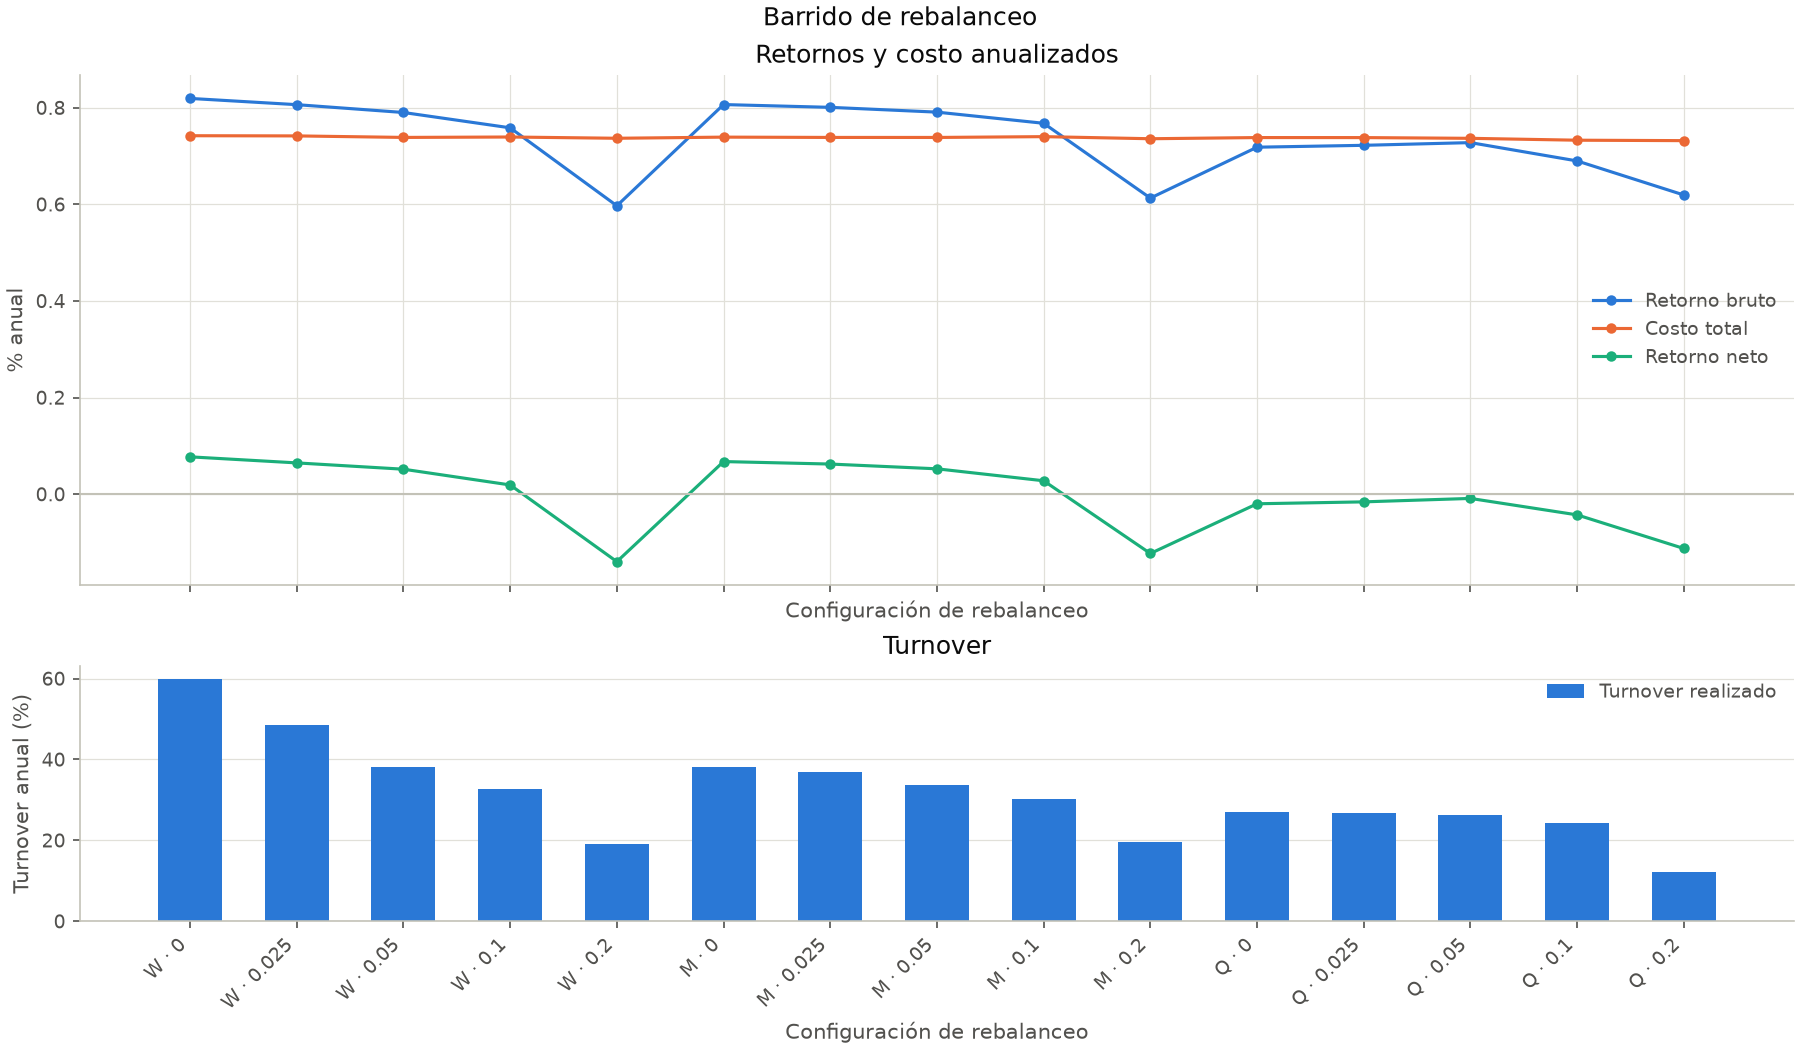

In [12]:
display(r["portafolio"]["sweep"]["train"])
display(Image(filename=FIGURES / "portafolio_barrido_rebalanceo.png"))

## Corrida base sobre train (P1, tarea 4)

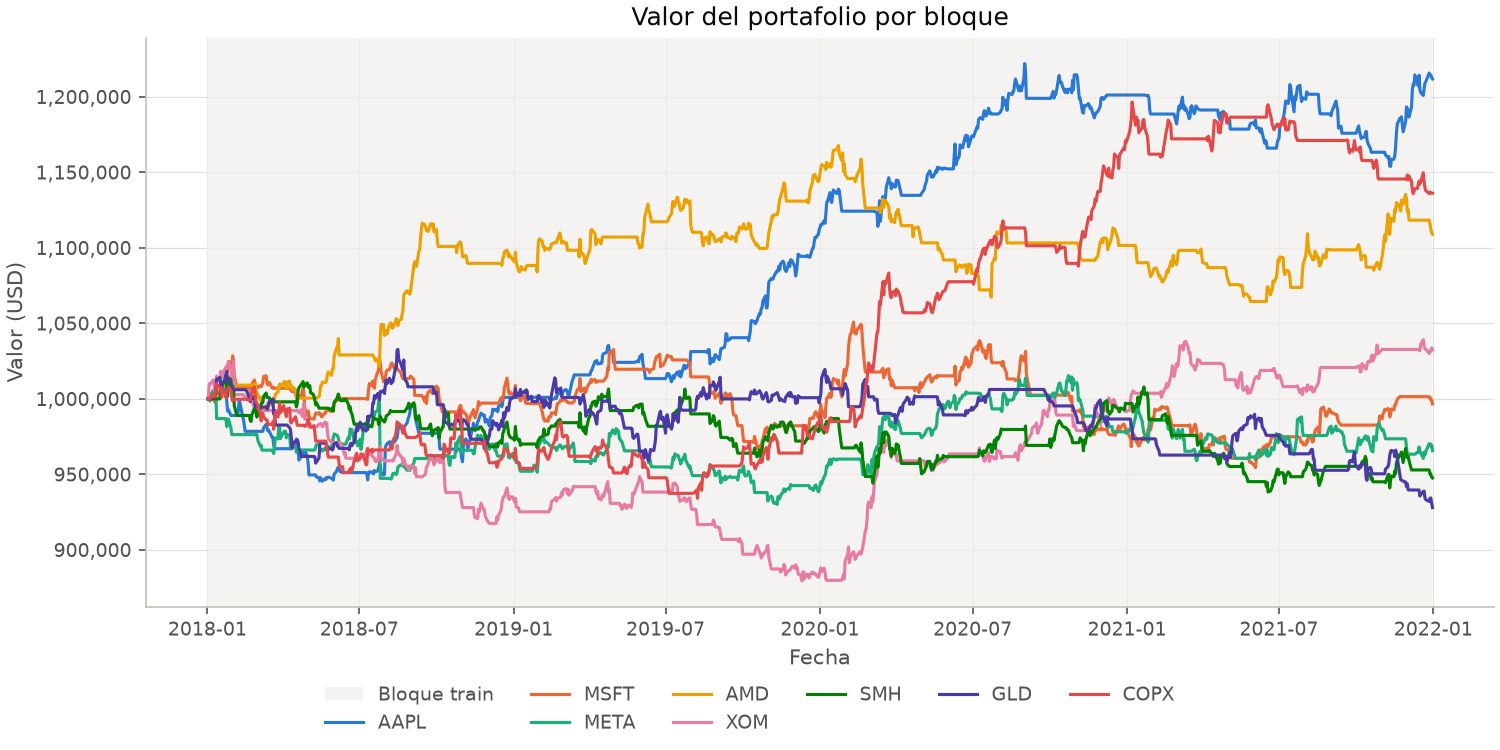

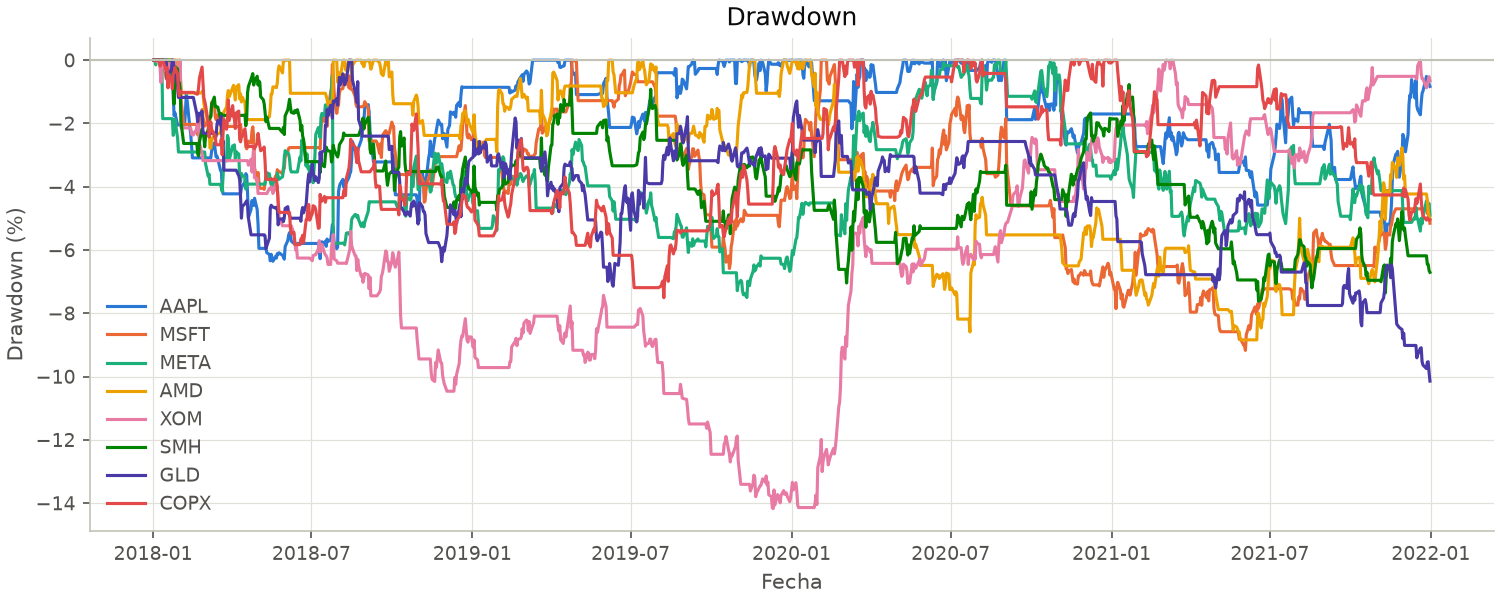

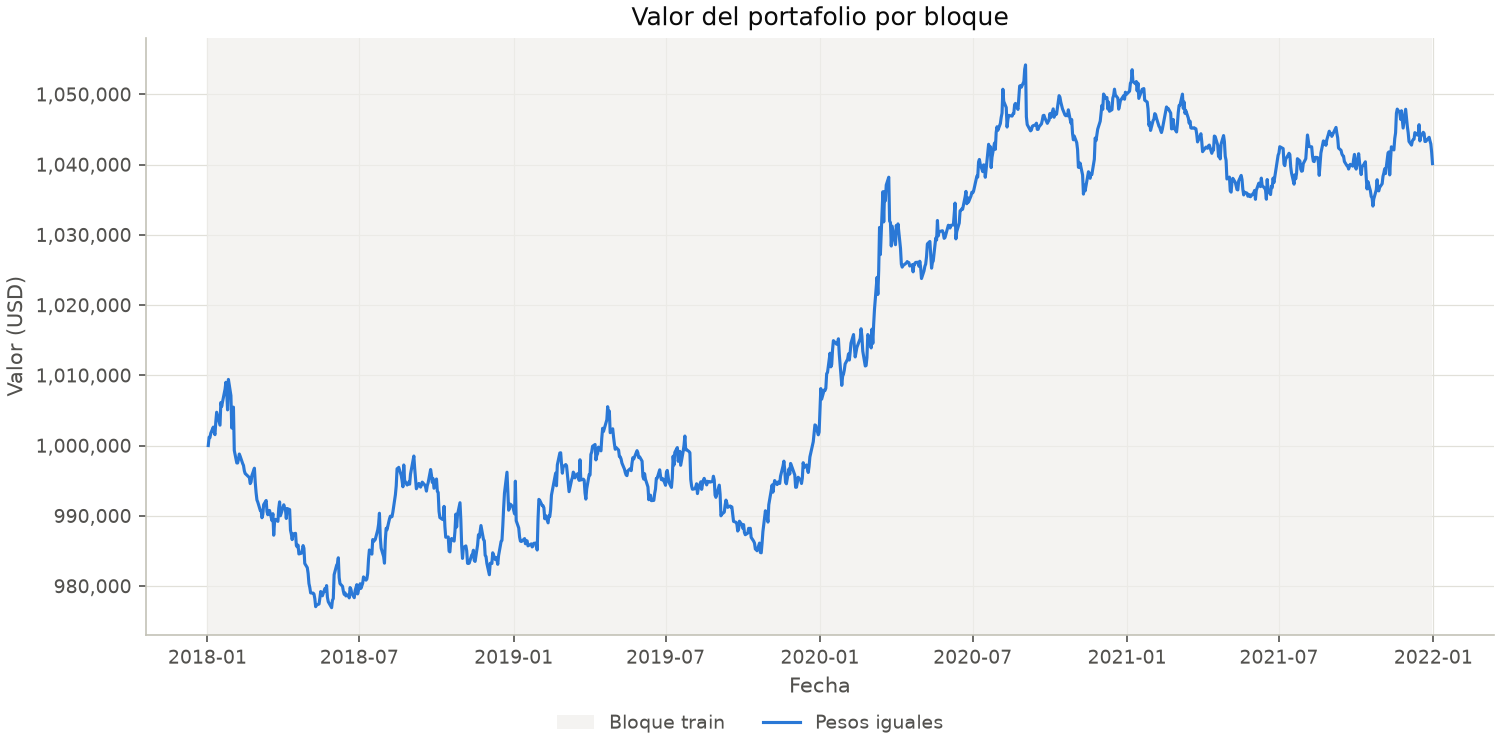

In [13]:
for name in ("base_equity_activos", "base_drawdown_activos", "base_equity_pesos_iguales"):
    display(Image(filename=FIGURES / f"{name}.png"))

## Estudios de diagnóstico (P2)

In [14]:
resumen = pd.DataFrame({k: v["user_attrs"] for k, v in r["diagnostico"]["studies"].items()}).T
display(resumen[["n_trials_evaluated", "n_trials_feasible", "minimum_trades", "elapsed_seconds"]])
display(pd.Series(r["diagnostico"]["plateau"], name="θ* (medoide de la meseta TPE)"))

,n_trials_evaluated,n_trials_feasible,minimum_trades,elapsed_seconds
random,200,200,192,11.0059
tpe,200,200,192,11.6970


sma_fast         19.0000
sma_slow         69.0000
rsi_window       11.0000
rsi_lo           28.0000
rsi_hi           68.0000
k_stop            3.3534
reward_ratio      1.4644
max_holding      39.0000
risk_per_trade    0.0188
Name: θ* (medoide de la meseta TPE), dtype: float64

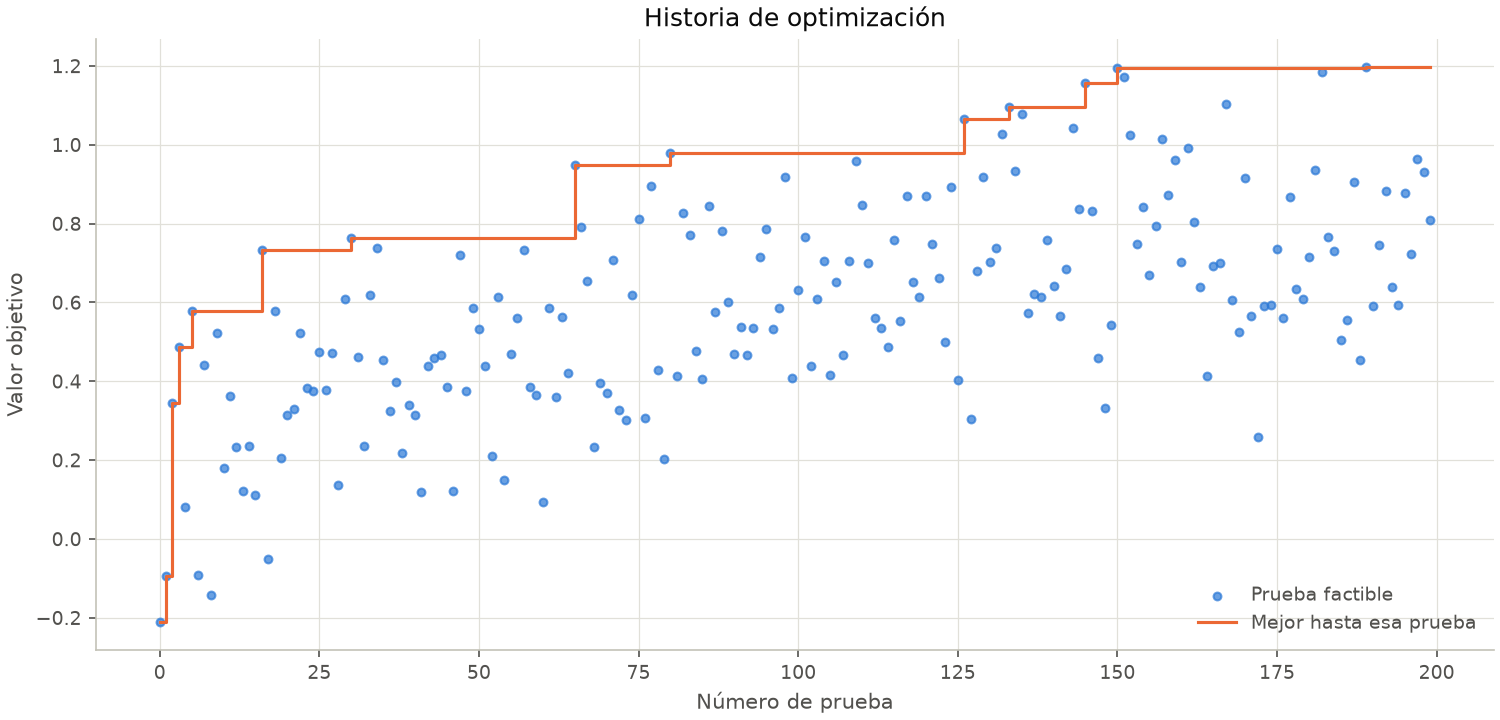

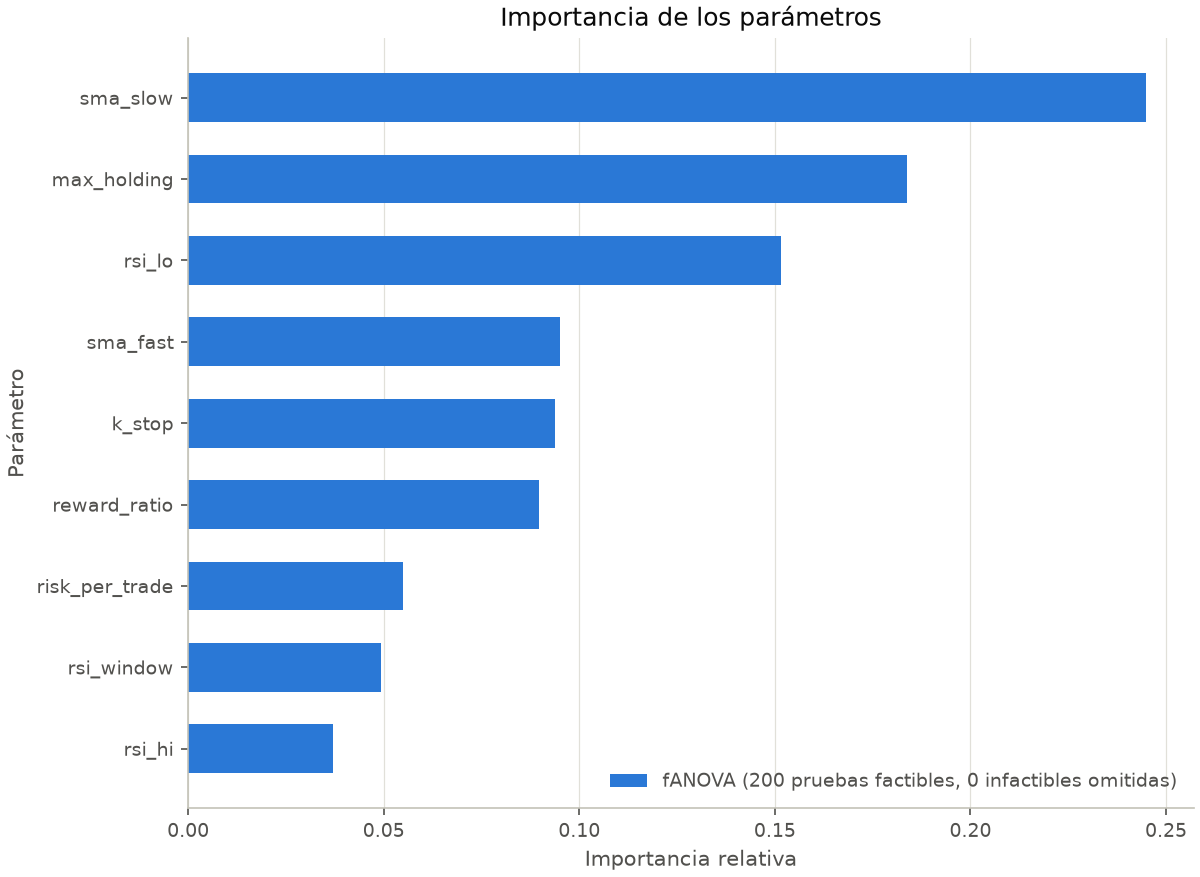

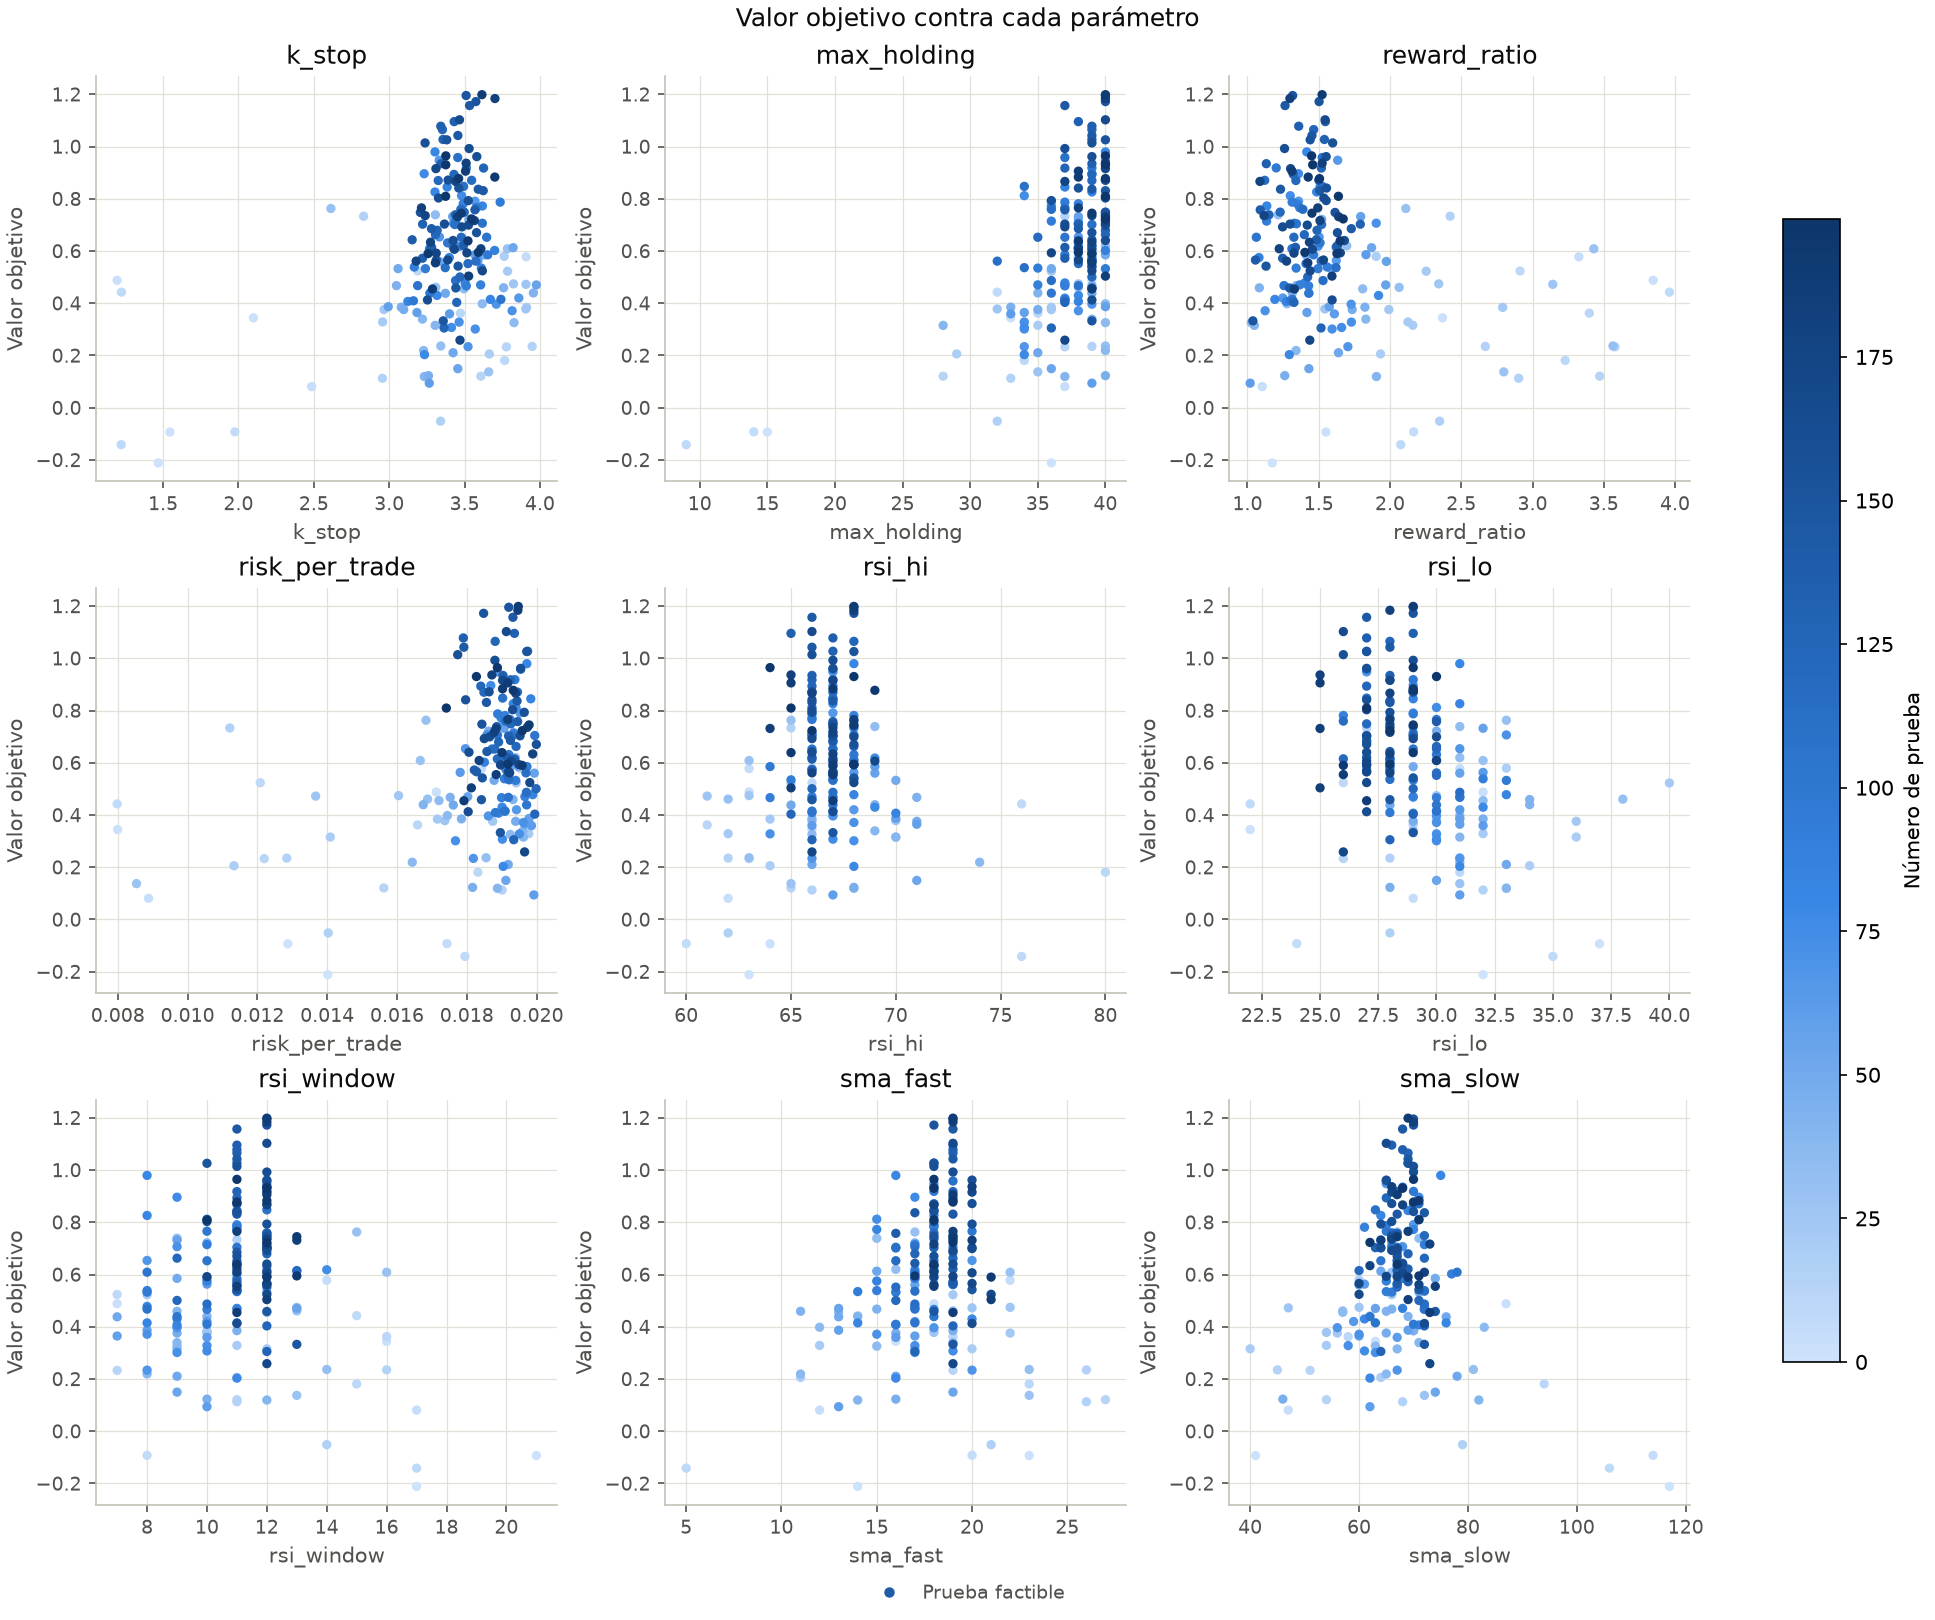

In [15]:
for name in ("diagnostico_historia_tpe", "diagnostico_importancia_tpe", "diagnostico_slices_tpe"):
    display(Image(filename=FIGURES / f"{name}.png"))

### Superficie 3D del random search (corte de 2 de las 9 dimensiones)

Dimensiones: sma_slow y max_holding


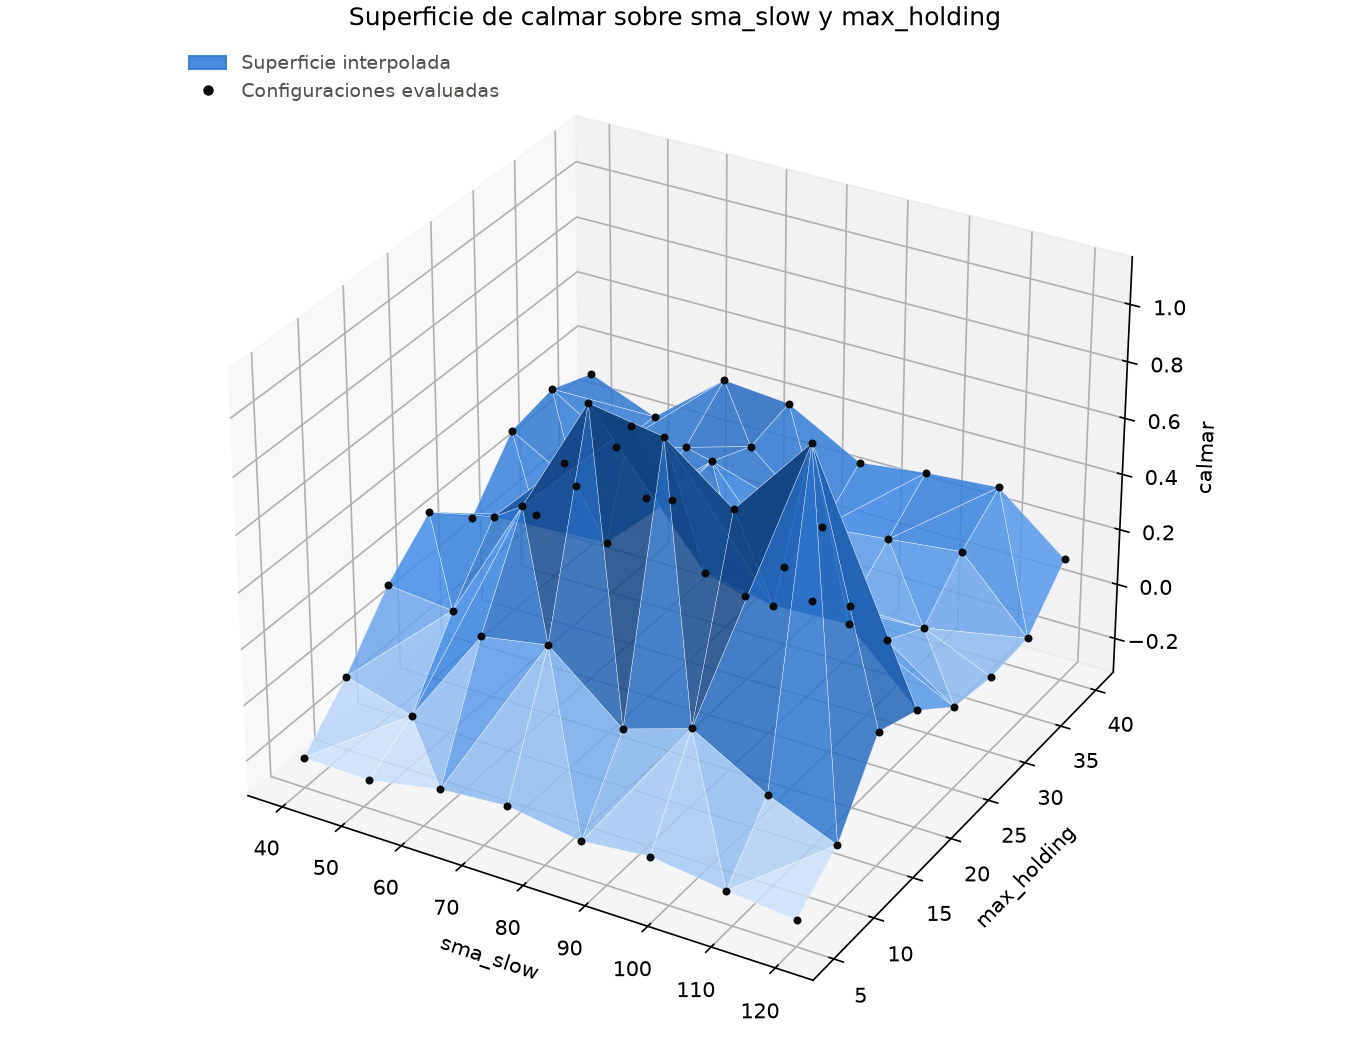

In [16]:
superficie = r["diagnostico"]["surface"]
print("Dimensiones:", superficie["x"], "y", superficie["y"])
display(Image(filename=FIGURES / "diagnostico_superficie_random.png"))

## Robustez con θ*, train (P2)

### Sensibilidad ±20%

factor,0.8000,1.2000
parameter,,
k_stop,-0.4103,-0.5184
max_holding,-0.6993,-0.2107
reward_ratio,-0.1134,-0.5467
risk_per_trade,-0.0027,-0.0053
rsi_hi,-0.1252,0.0344
rsi_lo,-0.0609,0.0376
rsi_window,0.0399,0.0303
sma_fast,-0.3694,-0.6366
sma_slow,-0.6380,-0.8081


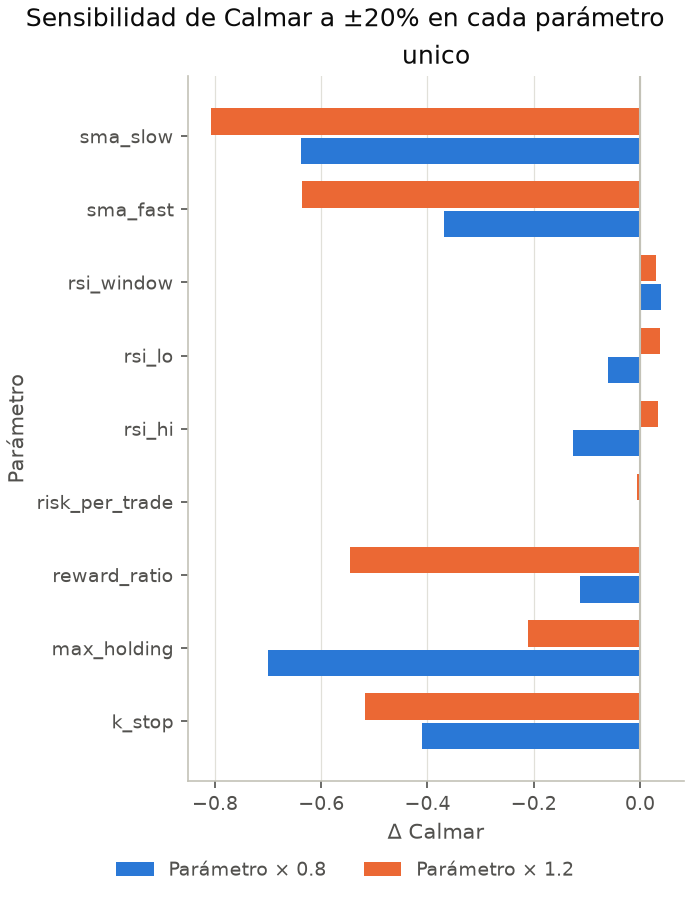

In [17]:
display(r["robustez"]["sensitivity"].pivot_table(index="parameter", columns="factor", values="delta_calmar"))
display(Image(filename=FIGURES / "robustez_sensibilidad.png"))

### Curva de costos

,net_return,calmar,n_trades
round_trip_bps,,,
0.0000,0.0376,1.5217,283
5.0000,0.0359,1.4296,282
10.0000,0.0345,1.3543,282
15.0000,0.0324,1.2565,283
20.0000,0.0309,1.1818,283
25.0000,0.0295,1.1130,283
30.0000,0.0281,1.0460,283
35.0000,0.0267,0.9809,283
40.0000,0.0245,0.8884,283


break_even_bps       NaN
base_cost_bps    29.0000
margin_bps           NaN
Name: 0.0, dtype: float64

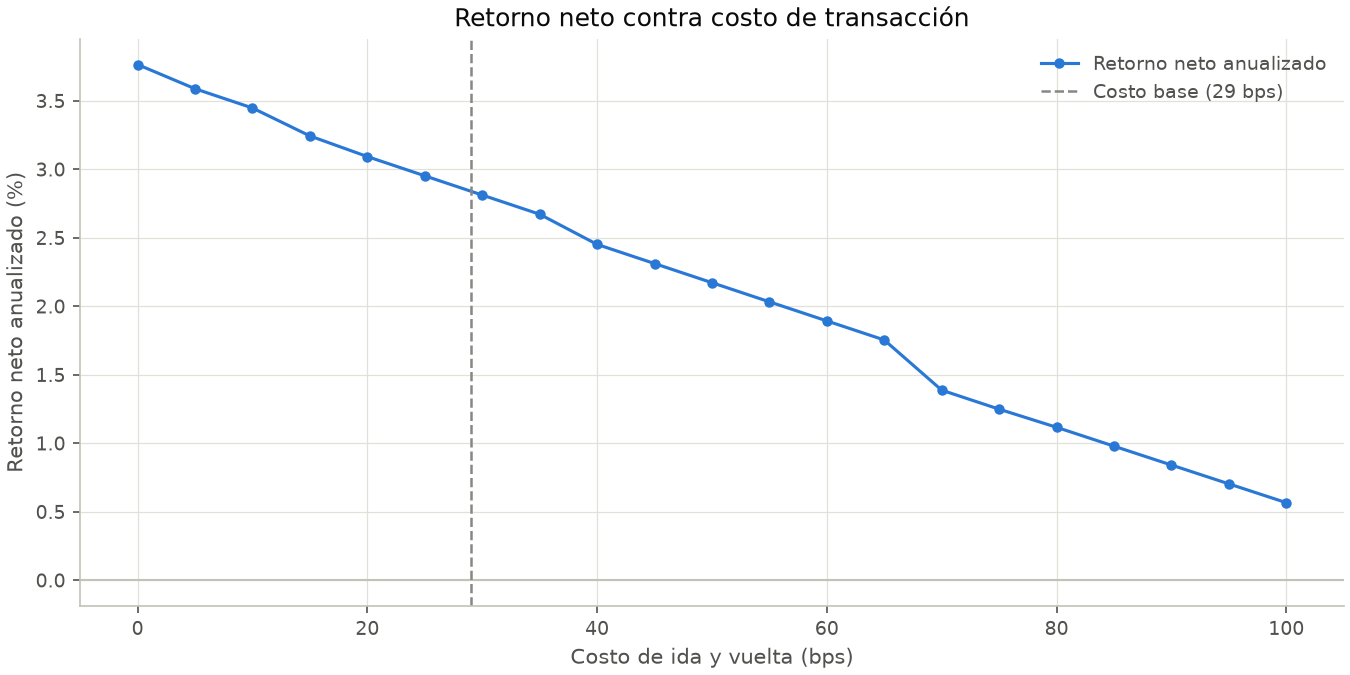

In [18]:
curva = r["robustez"]["cost_curve"]
display(curva[["net_return", "calmar", "n_trades"]])
display(curva[["break_even_bps", "base_cost_bps", "margin_bps"]].iloc[0])
display(Image(filename=FIGURES / "robustez_costos.png"))

### Pregunta 1: cada indicador solo contra la regla 2 de 3

In [19]:
display(r["robustez"]["single_indicator"])

,n_trades,calmar
strategy,,
2_de_3,283,1.0592
sma,203,0.7217
macd,656,-0.1849
rsi,990,-0.2391


### Correlación de votos SMA–MACD (SPEC punto 9)

In [20]:
display(r["robustez"]["sma_macd_correlation"])

,correlation,n_obs
ticker,,
AAPL,-0.1072,1008
MSFT,-0.1665,1008
META,-0.0998,1008
AMD,-0.1416,1008
XOM,-0.1488,1008
SMH,-0.1905,1008
GLD,-0.1412,1008
COPX,-0.1553,1008
pooled,-0.1351,8064


## Walk-forward (P2)

In [21]:
wf = r["walk_forward"]
print(f"Configuraciones evaluadas: {wf['n_trials_total']:,} · tiempo de optimización: "
      f"{wf['elapsed_seconds'] / 60:,.1f} min")
eficiencia = pd.DataFrame({"ann_return": wf["efficiency"], "calmar": wf["efficiency_calmar"]})
eficiencia.index.names = ["modo", "por_regimen"]
display(eficiencia)

Configuraciones evaluadas: 88,200 · tiempo de optimización: 25.8 min


ann_return  calmar
modo     por_regimen                    
rolling  True            -0.0096 -0.0011
         False           -0.1446 -0.0110
anchored True            -0.1275 -0.0395
         False           -0.1354 -0.0384

### Ventanas del walk-forward rolling por régimen: IS contra OOS

In [22]:
ventanas = wf["folds"][("rolling", True)]
display(ventanas[["is_calmar", "oos_calmar", "is_ann_return", "oos_ann_return"]].describe())
print("Ventanas con algún régimen en efectivo:", (ventanas["cash_regimes"] != "").sum())
display(ventanas.tail(12))

,is_calmar,oos_calmar,is_ann_return,oos_ann_return
count,66.0000,66.0000,66.0000,66.0000
mean,7.9129,9.8070,0.0318,0.0014
std,6.8815,41.3145,0.0219,0.0511
min,-0.1511,-11.8950,-0.0011,-0.0988
25%,3.6405,-7.0993,0.0179,-0.0333
50%,6.5155,-1.2640,0.0292,-0.0035
75%,9.5919,10.6594,0.0409,0.0259
max,39.2525,302.3674,0.1165,0.2053


Ventanas con algún régimen en efectivo: 0


,test_start,is_calmar,oos_calmar,is_ann_return,oos_ann_return,oos_trades,cash_regimes,n_trials,seconds
fold,,,,,,,,,
54,2023-01-01,2.3639,41.5754,0.0079,0.0317,7,,300,52.3839
55,2023-02-01,5.2478,-11.8950,0.0091,-0.0168,3,,300,53.0309
56,2023-03-01,8.5138,-7.8521,0.0086,-0.0423,5,,300,52.7772
57,2023-04-01,3.6370,2.3867,0.0131,0.0094,4,,450,75.9443
58,2023-05-01,3.3060,79.7247,0.0093,0.0480,4,,450,75.9528
59,2023-06-01,7.0292,-0.2550,0.0299,-0.0005,2,,450,75.8847
60,2023-07-01,9.2180,-7.0495,0.0413,-0.0458,1,,450,74.8984
61,2023-08-01,3.8006,-6.1834,0.0189,-0.0348,4,,300,54.6111
62,2023-09-01,4.8895,-7.1158,0.0396,-0.0516,5,,300,53.9508


## θ por régimen contra θ único y desempeño por régimen (P3, pregunta 5)

ann_return  ann_vol  sharpe  calmar  max_drawdown  n_trades  win_rate
modo     variante    bloque                                                                           
rolling  por régimen train           0.0067   0.0177 -0.1770  0.2991       -0.0224  232.0000    0.3362
                     validation     -0.0125   0.0126 -3.7561 -0.4373       -0.0286  120.0000    0.2250
         θ único     train          -0.0023   0.0186 -0.6470 -0.0597       -0.0378  214.0000    0.2991
                     validation     -0.0084   0.0120 -3.6007 -0.3803       -0.0220  110.0000    0.3182
anchored por régimen train          -0.0035   0.0206 -0.6433 -0.1075       -0.0326  209.0000    0.3876
                     validation     -0.0001   0.0129 -2.7254 -0.0077       -0.0112   85.0000    0.1529
         θ único     train          -0.0046   0.0221 -0.6470 -0.1317       -0.0346  240.0000    0.4250
                     validation      0.0016   0.0145 -2.3022  0.1236       -0.0126  107.0000    0.2430

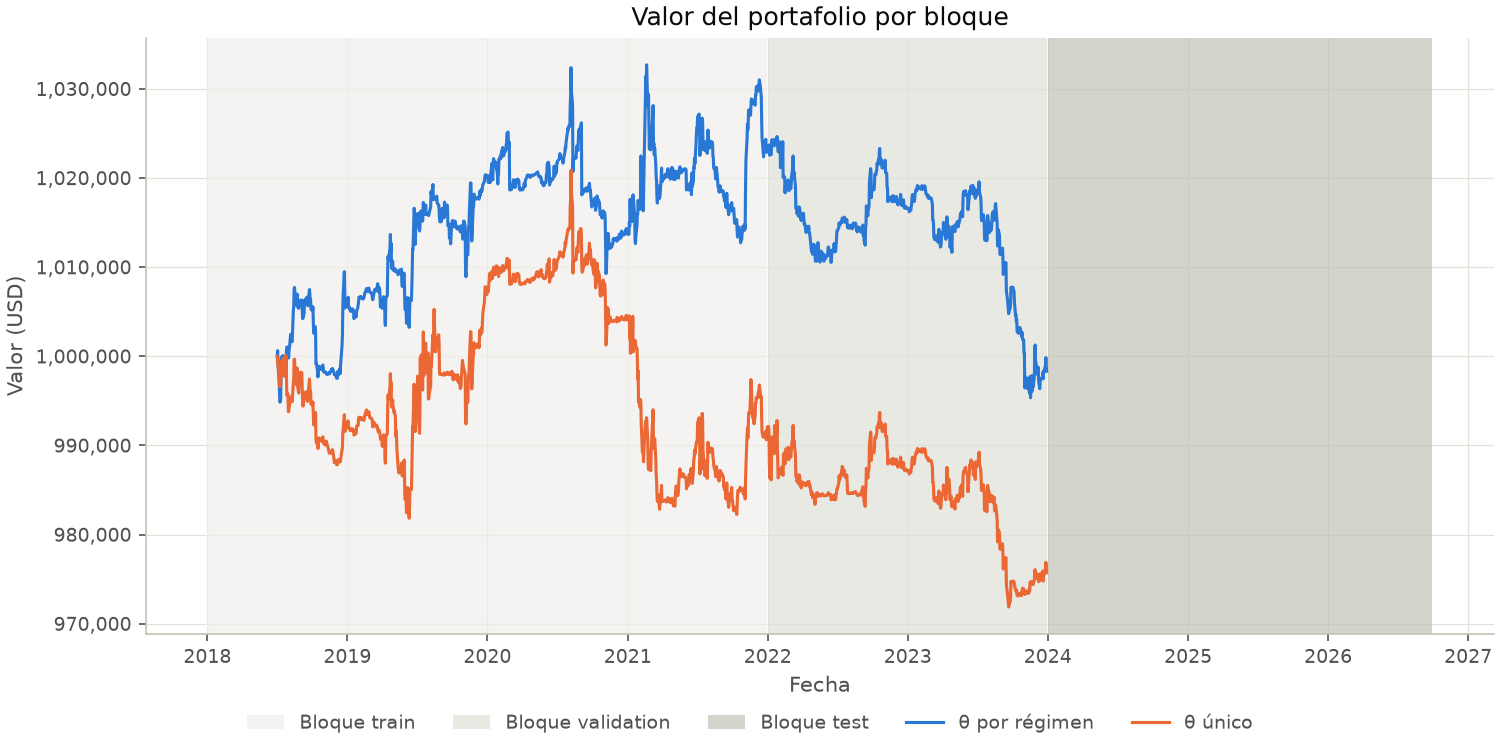

In [23]:
display(r["regimen_desempeno"]["theta_comparison"][columnas])
display(Image(filename=FIGURES / "regimen_theta_por_regimen_vs_unico.png"))

n_days  ann_return  sharpe  max_drawdown  n_trades  win_rate
variante    bloque     regimen                                                                 
por régimen train      tendencia 373.0000      0.0285  0.9253       -0.0123  112.0000    0.3393
                       reversion 272.0000     -0.0159 -1.8652       -0.0230   73.0000    0.3151
                       crisis    237.0000     -0.0010 -0.8302       -0.0153   47.0000    0.3617
            validation tendencia 152.0000      0.0112 -2.9709       -0.0065   23.0000    0.0870
                       reversion  93.0000     -0.0689 -7.2602       -0.0267   24.0000    0.0833
                       crisis    256.0000     -0.0053 -2.6187       -0.0135   73.0000    0.3151
θ único     train      tendencia 373.0000      0.0042 -0.2113       -0.0253   99.0000    0.2727
                       reversion 272.0000     -0.0101 -0.9466       -0.0225   67.0000    0.3284
                       crisis    237.0000     -0.0033 -1.4104       -0.0099   48.0000    0.3125
            validation tendencia 152.0000     -0.0061 -3.7779       -0.0069   27.0000    0.1852
                       reversion  93.0000     -0.0416 -6.3684       -0.0198   26.0000    0.3462
                       crisis    256.0000      0.0027 -2.2183       -0.0092   57.0000    0.3684

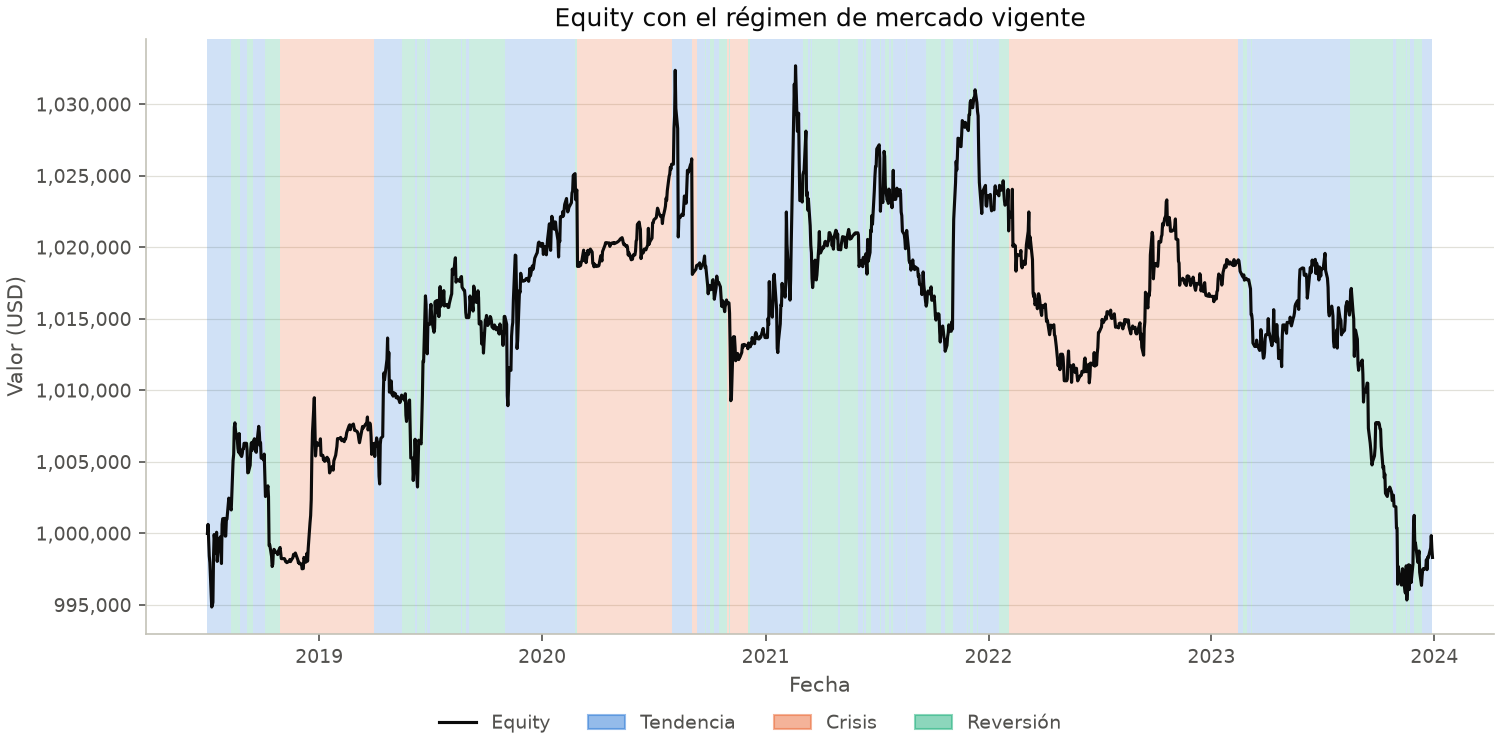

In [24]:
por_regimen = r["regimen_desempeno"]["by_regime"]
display(por_regimen.loc["rolling"][["n_days", "ann_return", "sharpe", "max_drawdown", "n_trades", "win_rate"]])
display(Image(filename=FIGURES / "regimen_equity_oos.png"))

## Backtests finales (walk-forward rolling por régimen)

### Métricas por bloque contra pesos iguales, buy & hold y cada activo

In [25]:
final = r["final_backtests"]
print("Bloques medidos:", {k: (str(a.date()), str(b.date())) for k, (a, b) in final["blocks"].items()})
display(final["metrics_by_block"][columnas].unstack("bloque").round(3))

Bloques medidos: {'train': ('2018-07-01', '2021-12-31'), 'validation': ('2022-01-01', '2023-12-31')}


ann_return            ann_vol             sharpe             calmar            max_drawdown            n_trades            win_rate           
bloque             train validation   train validation   train validation   train validation        train validation    train validation    train validation
estrategia                                                                                                                                                  
Risk Parity      -0.0050    -0.0040  0.0180     0.0140 -0.7810    -2.7290 -0.1550    -0.1550      -0.0290    -0.0260      308        160   0.3860     0.4310
Pesos iguales    -0.0030    -0.0020  0.0160     0.0140 -0.8020    -2.6950 -0.1300    -0.0810      -0.0230    -0.0210      308        160   0.3860     0.4310
AAPL              0.0450    -0.0410  0.0530     0.0480  0.6790    -1.5920  0.8100    -0.4330      -0.0560    -0.0950       37         19   0.5140     0.4210
MSFT             -0.0030    -0.0480  0.0570     0.0540 -0.1970    -1.5350 -0.0290    -0.4170      -0.1020    -0.1140       35         21   0.3430     0.3330
META             -0.0200     0.0740  0.0530     0.0640 -0.5440     0.5960 -0.1660     1.0100      -0.1220    -0.0730       33         21   0.3940     0.5710
AMD               0.0030     0.0440  0.0610     0.0570 -0.0820     0.1610  0.0220     0.7830      -0.1400    -0.0560       47         20   0.3830     0.3500
XOM              -0.0070    -0.0110  0.0660     0.0390 -0.2240    -1.1770 -0.0800    -0.2190      -0.0870    -0.0500       38         18   0.3950     0.5000
SMH              -0.0050    -0.0330  0.0570     0.0540 -0.2350    -1.2520 -0.0520    -0.4170      -0.0950    -0.0790       39         21   0.3590     0.3330
GLD               0.0020     0.0140  0.0540     0.0630 -0.1260    -0.3000  0.0200     0.1550      -0.0840    -0.0930       42         21   0.3570     0.5240
COPX              0.0070     0.0000  0.0600     0.0540 -0.0170    -0.6280  0.0650     0.0010      -0.1100    -0.0630       42         19   0.3810     0.4210
Buy & hold        0.4000     0.0780  0.2880     0.2290  1.2790     0.2890  1.3190     0.3100      -0.3030    -0.2510        0          0      NaN        NaN

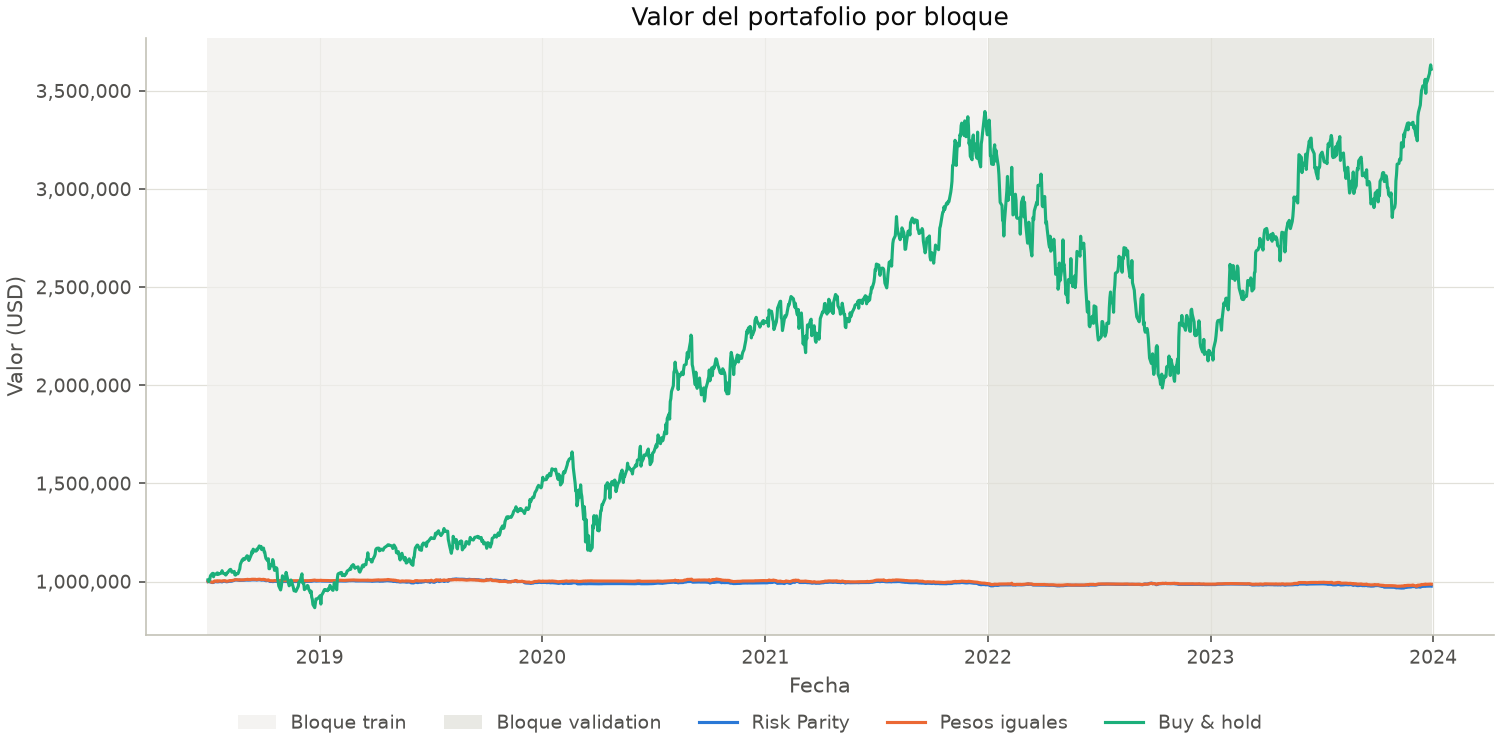

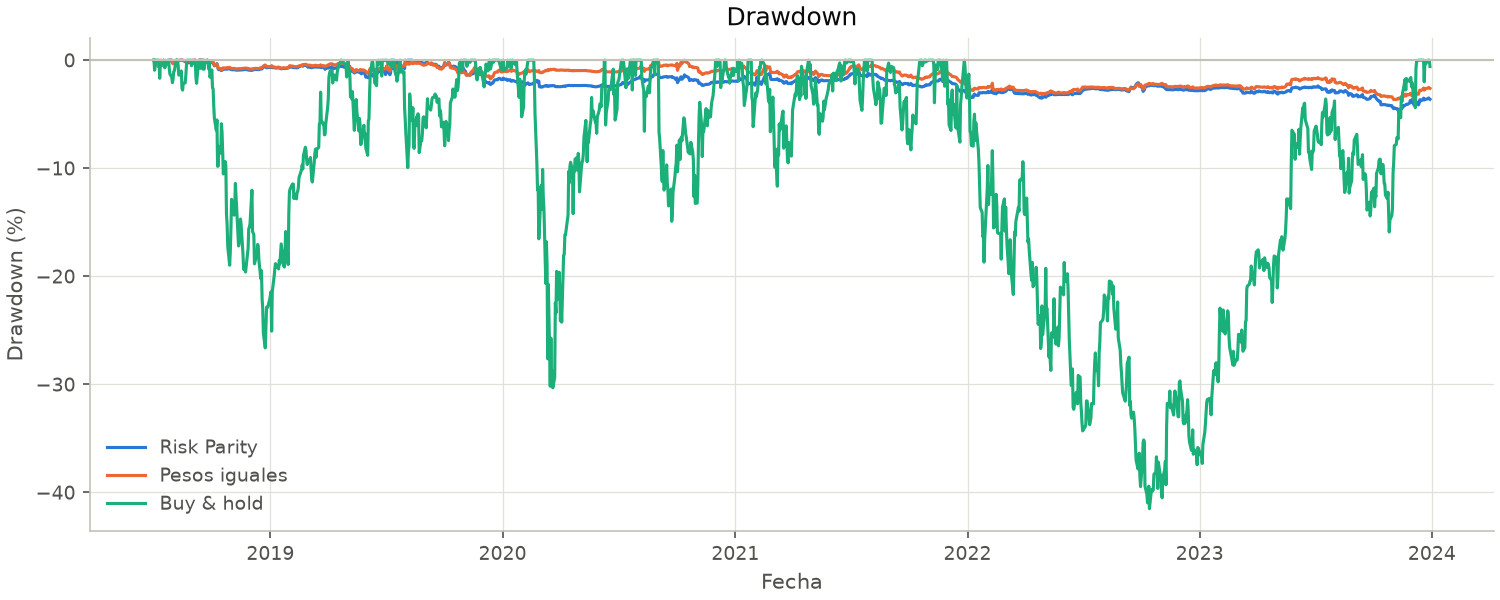

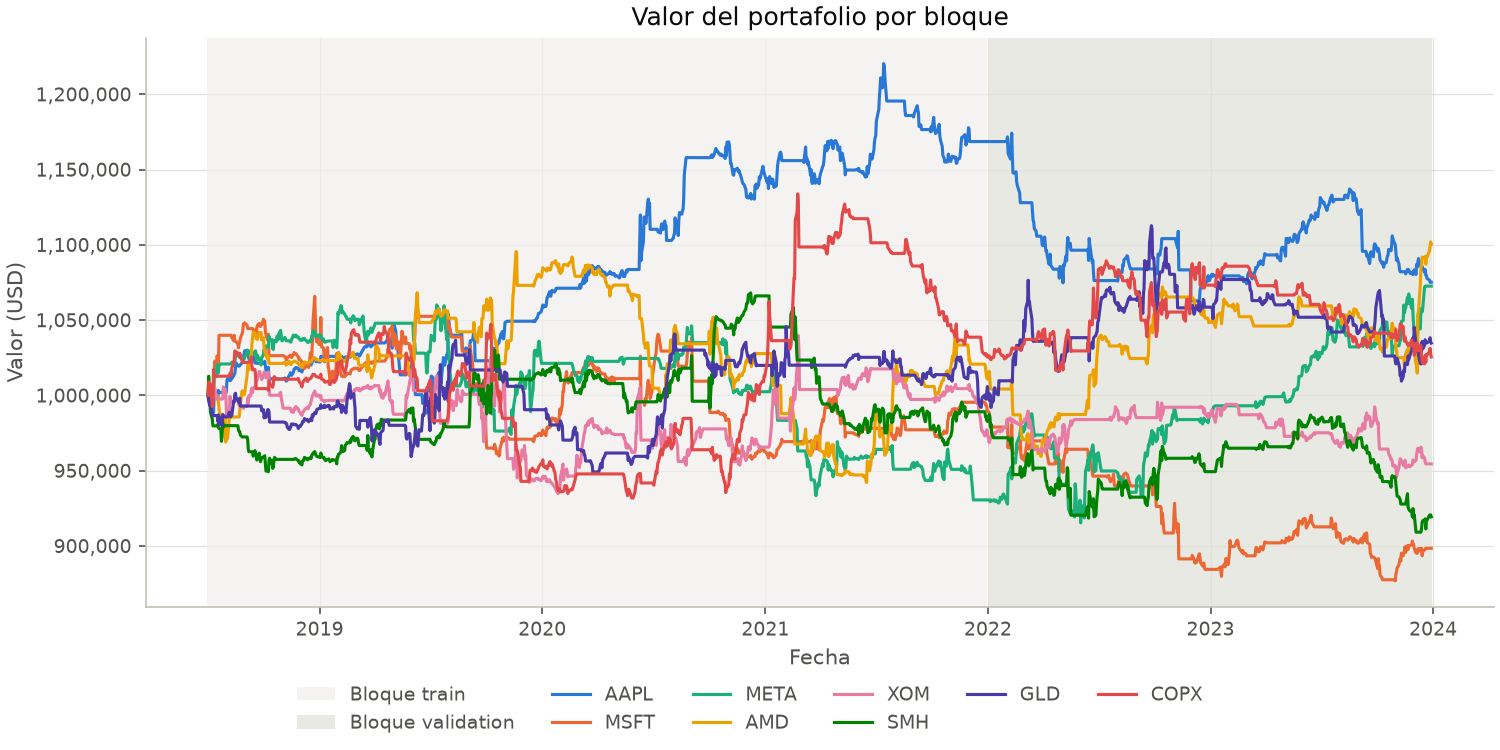

In [26]:
for name in ("final_equity", "final_drawdown", "final_equity_activos"):
    display(Image(filename=FIGURES / f"{name}.png"))

### Retornos mensuales, trimestrales y anuales de Risk Parity

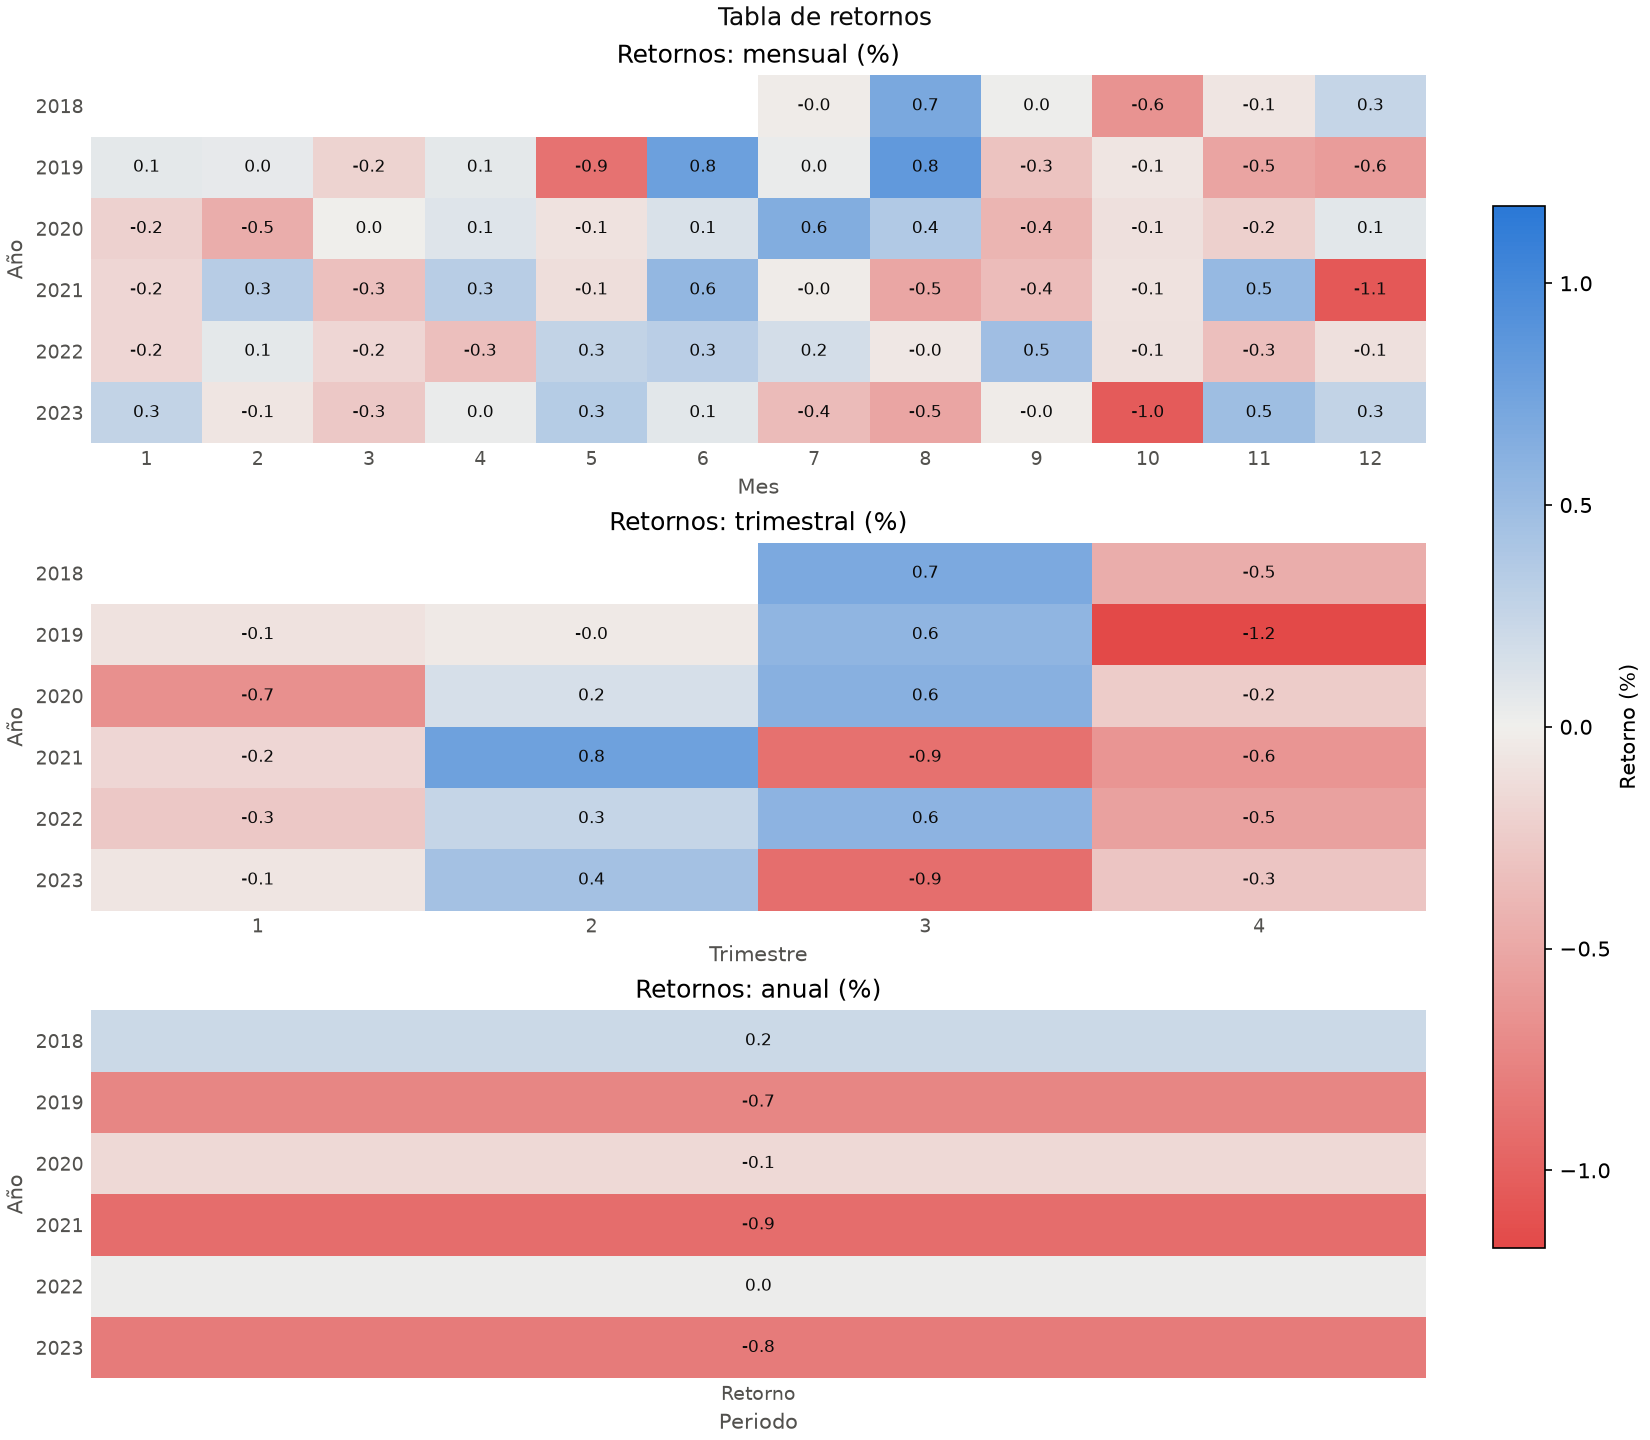

In [27]:
display(Image(filename=FIGURES / "final_retornos_risk_parity.png"))

### Exposición, break-even y señales

In [28]:
for name, metrics in final["exposure"].items():
    print(name, f"· tiempo en mercado {metrics['time_in_market_portfolio']:.0%}",
          f"· {metrics['trades_per_month']:.1f} operaciones/mes")
    display(metrics["exit_reasons"].to_frame().T)
display(final["breakeven"])

Risk Parity · tiempo en mercado 77% · 5.6 operaciones/mes


exit_reason,signal,stop,target,max_holding
count,55,190,68,155


Pesos iguales · tiempo en mercado 77% · 5.6 operaciones/mes


exit_reason,signal,stop,target,max_holding
count,55,190,68,155


,theoretical_win_rate,empirical_breakeven_win_rate,observed_win_rate,payoff_ratio,cost_in_r
train,0.2590,0.4127,0.3864,1.4228,0.0460
validation,0.2590,0.4560,0.4313,1.1931,0.0460


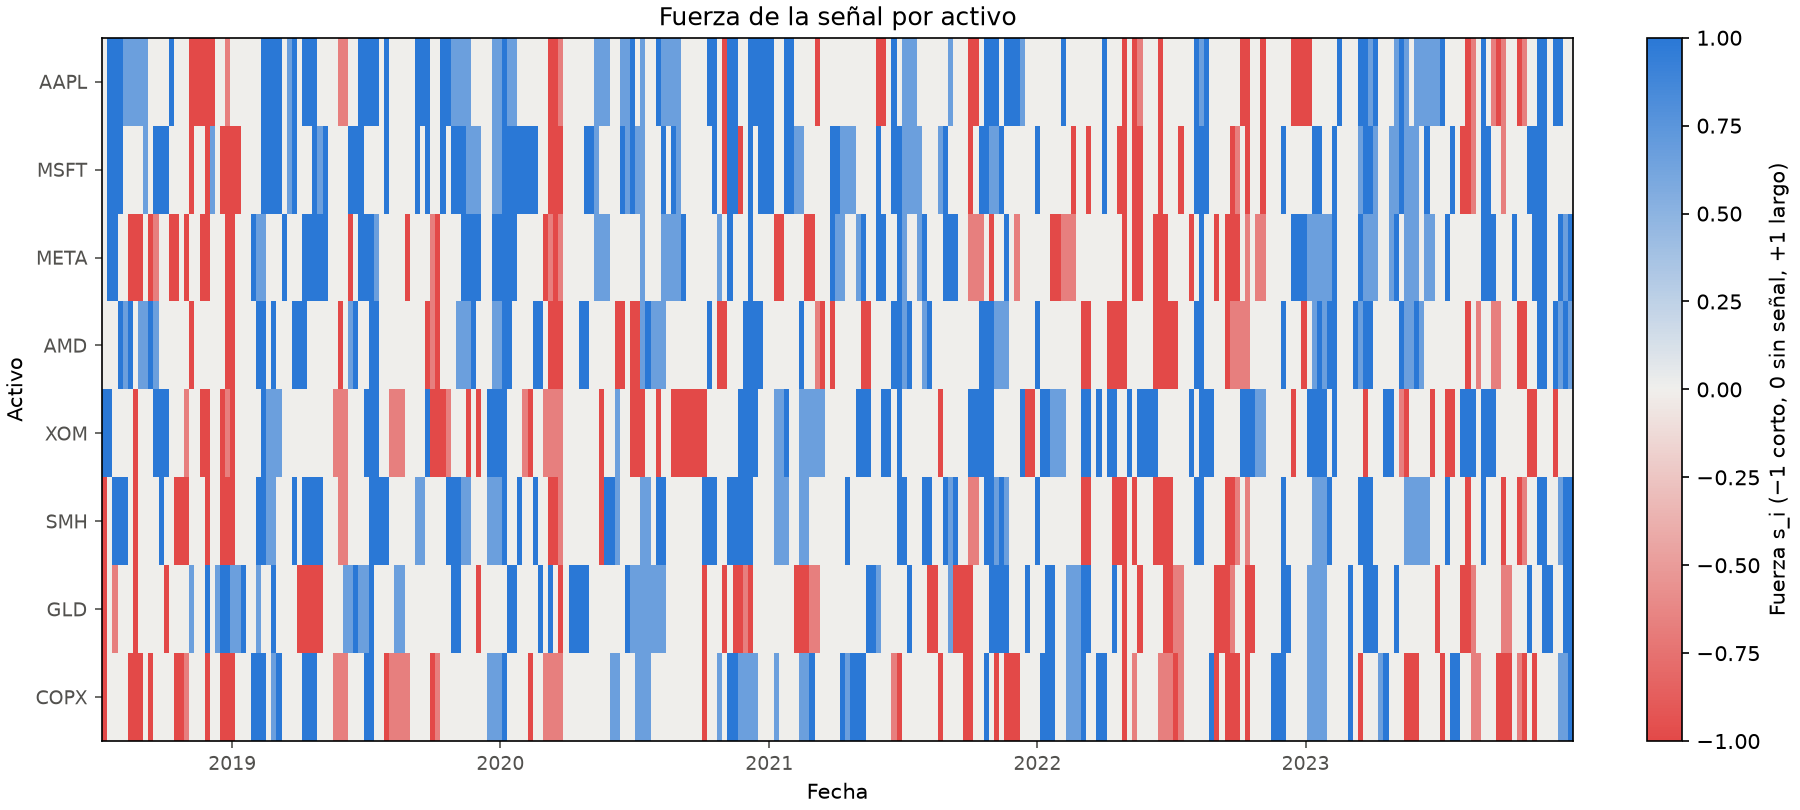

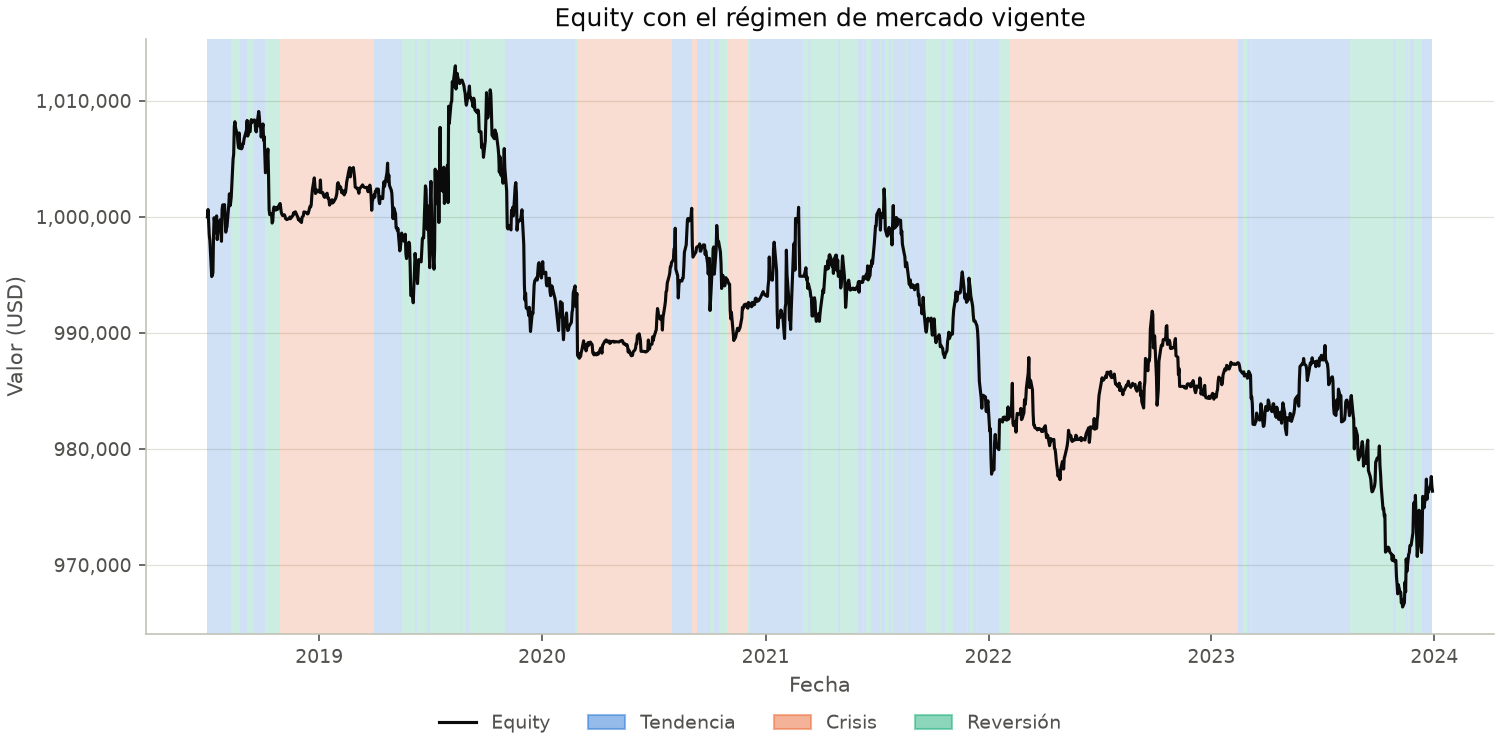

In [29]:
display(Image(filename=FIGURES / "final_mapa_senales.png"))
display(Image(filename=FIGURES / "final_equity_regimen.png"))

## Impacto de mercado ex post (P1, tarea 10)

In [30]:
impacto = r["impacto_mercado"]["summary"]
display(pd.Series({k: v for k, v in impacto.items() if k != "by_ticker_bps"}))
display(impacto["by_ticker_bps"].rename("bps promedio por llenado"))

block                (2022-01-01 00:00:00, 2023-12-31 00:00:00)
n_trades                                                    160
mean_bps                                                 0.8538
median_bps                                               0.3531
p95_bps                                                  4.9720
max_participation                                        0.0011
impact_cost                                            450.7151
impact_pct_equity                                        0.0005
block_return                                            -0.0053
impact_pct_return                                       -0.0872
dtype: object

ticker
AAPL   0.1839
AMD    0.2297
COPX   4.4857
GLD    0.6328
META   0.2655
MSFT   0.2077
SMH    0.5337
XOM    0.4917
Name: bps promedio por llenado, dtype: float64

## Auditoría de sesgos (P1, tarea 5)

In [31]:
display(Markdown((RESULTS / "auditoria_sesgos.md").read_text(encoding="utf-8")))

# Auditoría de sesgos

| Sesgo | Evidencia |
|---|---|
| Look-ahead | La señal de t se ejecuta al Open de t+1 y ese desplazamiento solo existe en `run_backtest`. Pruebas de truncamiento en verde para indicadores y señales (`test_signals.py`), régimen (`test_regimes.py`), pesos (`test_portfolio.py`) y el pipeline completo (`test_pipeline.py`); golden test 9 (t → t+1). El régimen operado es la etiqueta filtrada (forward); Viterbi solo aparece en una figura. |
| Survivorship | Los 8 activos se eligieron en 2026 entre empresas y ETFs que sobrevivieron hasta hoy, así que el resultado está sesgado al alza. Datos completos y traslapados: 2,449 días comunes de 2017-01-03 a 2026-09-30, 0 fechas descartadas y 0 incidencias de calidad. |
| Overfitting / data snooping | Optuna TPE con 150 pruebas por estudio y ventana del walk-forward (88,200 configuraciones evaluadas en total), más 200 random y 200 TPE de diagnóstico. Se elige el medoide del mejor 10% (meseta), no el máximo. m(régimen) no entra al espacio de búsqueda. Eficiencia del walk-forward: rolling por régimen = -0.01, rolling θ único = -0.14, anchored por régimen = -0.13, anchored θ único = -0.14. Test se corre una sola vez con θ congelados. |
| Ejecución optimista | Ejecución al Open de t+1 con slippage de 2 bps en contra en todo llenado, incluidos SL y TP; comisión de 0.125% por lado y borrow en cortos. Empate intrabarra: primero el stop. Gap más allá del TP llena en el TP, sin mejora. Impacto de mercado no modelado; estimado ex post sobre 160 operaciones de validation: 0.9 bps promedio por llenado (p95 5.0 bps), 0.05% del equity inicial del bloque. |
| Selección de muestra / periodo | Rango 2017-01-02 → 2026-09-30 y partición train / validation / test fijados en el SPEC antes de ver resultados; 2017 solo calienta indicadores. El walk-forward corre continuo sobre los tres bloques. Validation se usa una vez para decisiones discretas. |
